# PhysioNet EEGMMIDB: Target-Adaptive FBGAN + CRNN-DF V3

This notebook is the next research-stage implementation of the
Zhang et al. (2023) hybrid subject-independent EEG framework.

Pipeline
--------
1. Local PhysioNet EEGMMIDB loader.
2. Objective subject-quality ranking for development experiments.
3. Training-only normalization.
4. 10-band OVR-FBCSP + LASSO sparse feature extraction.
5. Target-specific four-class FBGAN:
   - one generator per target class,
   - raw EEG discriminator D_phi,
   - sparse filter-bank discriminator D_psi.
6. 3,000 balanced generated trials by default:
   750 per class.
7. Source-subject EEG + target-specific generated EEG
   are used to adaptively train CRNN-DF.
8. Two-layer LSTM, hidden size 64.
9. Joint CrossEntropy + 0.1 Center Distance Loss.
10. Center initialization and centroid separation/update.
11. Early stopping is based only on SOURCE-subject validation data.
12. Final evaluation is performed only on the held-out target subject.

Research-protocol note
----------------------
The original Frontiers paper uses target-subject data to train the
target-specific FBGAN and reports the strongest augmentation result
with 3,000 generated trials (750 per class). This notebook therefore
provides a "paper-faithful adaptation" mode for reproducing that
protocol on PhysioNet.

For a leakage-resistant publication experiment, set:
    CFG.paper_faithful_target_adaptation = False
and use the target calibration fraction. The target test set then
remains unseen by FBGAN and CRNN-DF training.

The reported 72.74 +/- 10.44% in the paper is a BCI Competition IV-2a
result, not a PhysioNet result. The objective here is to transfer and
evaluate the methodology on PhysioNet, not to assume the same accuracy.


In [1]:
# CELL 1 - Environment Setup, Configuration, and Reproducibility
# ============================================================

import gc
import math
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, welch
from sklearn.linear_model import LassoCV
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset

warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

SEED = 42


def seed_everything(seed=SEED):
    """Seed Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()

DEVICE = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

# ============================================================
# RESEARCH CONFIGURATION
# ============================================================


@dataclass
class Config:
    # Dataset
    sfreq: int = 160
    epoch_seconds: float = 4.0
    n_channels: int = 64
    n_times: int = 640
    n_classes: int = 4

    # Local PhysioNet EEGMMIDB
    data_path: str = (
        "/Users/ashokvarmabevara/MtechProj/eegmmidb"
    )

    # Demonstration size.
    # Set to 109 after the pipeline is validated.
    num_subjects_to_test: int = 5

    # Select subjects by objective signal-quality ranking.
    # This is NOT based on model accuracy.
    quality_rank_all_109: bool = True
    quality_scan_limit: int = 109

    # LOSO target adaptation.
    paper_faithful_target_adaptation: bool = True

    # Used only when paper_faithful_target_adaptation=False.
    target_calibration_fraction: float = 0.20

    # Source validation only.
    source_validation_fraction: float = 0.10

    # Classifier
    batch_size: int = 32
    classifier_lr: float = 1e-4
    classifier_epochs: int = 100
    classifier_patience: int = 15
    weight_decay: float = 1e-4
    gradient_clip: float = 1.0

    # FBGAN
    gan_batch_size: int = 5
    gan_lr: float = 1e-4
    gan_epochs: int = 30
    latent_dim: int = 1600

    # Original paper uses 3,000 total = 750/class.
    fake_per_class: int = 750

    # Sparse FBCSP
    max_sparse_features: int = 64
    lasso_cv: int = 5

    # Center/discriminative feature learning
    lambda_center: float = 0.1
    center_update_every: int = 15
    center_alpha: float = 0.02

    # FBGAN auxiliary sparse-feature matching.
    sparse_gan_weight: float = 1.0

    # Runtime
    num_workers: int = 0
    debug_shapes: bool = False

    # Optional baseline comparison.
    run_crnn_baseline_ablation: bool = False


CFG = Config()

BANDS = [
    (1, 4),
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32),
    (32, 35),
    (35, 38),
]

CLASS_NAMES = {
    0: "Left Fist",
    1: "Right Fist",
    2: "Both Fists",
    3: "Both Feet",
}

print("Device:", DEVICE)
print("Dataset:", CFG.data_path)
print(
    "Expected EEG:",
    (CFG.n_channels, CFG.n_times),
)


Device: mps
Dataset: /Users/ashokvarmabevara/MtechProj/eegmmidb
Expected EEG: (64, 640)


# CELL 2 - Dimensionally Adapted Architecture Diagrams
# ============================================================

# ----------------------------------------------------------------
# CRNN-DF
#
# Input EEG
# (B, 1, 64, 640)
#       |
#       v
# Conv2D(1 -> 40, kernel=(64,45), stride=1)
#       |
# BN + ELU + Dropout
#       |
# MaxPool2D(kernel=(1,48), stride=(1,10))
#       |
# approximately (B,40,1,60)
#       |
# squeeze channel-height + transpose
#       |
# LSTM sequence: (B,60,40)
#       |
# 2-layer LSTM, hidden=64
#       |
# discriminative feature vector (B,64)
#       |
# CrossEntropy + 0.1 * CenterDistanceLoss
#       |
# 4-class logits
#
# ----------------------------------------------------------------
# Target-adaptive FBGAN
#
# Target class EEG
# (B,1,64,640)
#       |
#       +------------------------+
#       |                        |
#       v                        v
#      D_phi                  Filter bank
# raw EEG discriminator      10 bands, 1-38 Hz
#       |                        |
#       |                        v
#       |                 OVR-CSP + LASSO
#       |                        |
#       |                  sparse CSP maps
#       |                        |
#       |                        v
#       |                      D_psi
#       |               sparse-FB discriminator
#       |                        |
#       +-----------+------------+
#                   |
#                  GAN
#
# Generator:
#
# z (B,1600)
#      |
#      v
# FC -> (B,256,4,40)
#      |
# 5 transposed-convolution stages
#      |
#      v
# fake EEG (B,1,64,640)
#
# Four GANs are trained sequentially:
# one generator/discriminator pair for each MI class.
#
# D_phi spatial kernel: (64,1)
# D_psi spatial kernel: (64,1)
#
# ----------------------------------------------------------------
# IMPORTANT
#
# The paper explicitly uses sparse CSP filter-bank information as
# part of FBGAN and target-specific generated samples for adaptive
# classifier training. The PhysioNet adaptation below preserves this
# principle while changing 22 -> 64 channels and 1000 -> 640 samples.
#
print("Architecture diagrams loaded.")


In [2]:
# ============================================================
# CELL 3 - LOCAL PHYSIONET EEGMMIDB DATA LOADER
# ============================================================
# This notebook uses the already-downloaded PhysioNet EEGMMIDB
# dataset directly from the local Mac filesystem.
#
# Expected structure:
#
# /Users/ashokvarmabevara/MtechProj/eegmmidb/
# ├── S001/
# │   ├── S001R04.edf
# │   ├── S001R06.edf
# │   ├── S001R08.edf
# │   ├── S001R10.edf
# │   ├── S001R12.edf
# │   └── S001R14.edf
# ├── S002/
# └── ...
# ============================================================

from pathlib import Path

import mne
import numpy as np
from scipy.signal import resample


# ============================================================
# DATASET CONFIGURATION
# ============================================================

DATASET_ROOT = Path(
    "/Users/ashokvarmabevara/MtechProj/eegmmidb"
)

TARGET_FS = 160
TRIAL_DURATION = 4.0

N_CHANNELS = 64
N_SAMPLES = int(TARGET_FS * TRIAL_DURATION)

LEFT_RIGHT_RUNS = [4, 8, 12]
HANDS_FEET_RUNS = [6, 10, 14]

ALL_RUNS = (
    LEFT_RIGHT_RUNS
    + HANDS_FEET_RUNS
)

CLASS_NAMES = {
    0: "Left Fist",
    1: "Right Fist",
    2: "Both Fists",
    3: "Both Feet",
}


# ============================================================
# DATASET VALIDATION
# ============================================================

def check_dataset_structure():
    """Validate the local EEGMMIDB dataset structure."""

    print("=" * 70)
    print("LOCAL PHYSIONET EEGMMIDB DATASET CHECK")
    print("=" * 70)

    print(f"Dataset path: {DATASET_ROOT}")
    print(f"Dataset exists: {DATASET_ROOT.exists()}")

    if not DATASET_ROOT.exists():
        raise FileNotFoundError(
            "Dataset folder was not found:\n"
            f"{DATASET_ROOT}"
        )

    subject_dirs = sorted(
        [
            path
            for path in DATASET_ROOT.iterdir()
            if path.is_dir()
            and path.name.startswith("S")
        ]
    )

    print(
        f"\nNumber of subject folders found: "
        f"{len(subject_dirs)}"
    )

    if len(subject_dirs) == 0:
        raise RuntimeError(
            "No subject folders were found in the dataset."
        )

    print("\nFirst 10 subject folders:")

    for subject_dir in subject_dirs[:10]:
        print(subject_dir.name)

    print("=" * 70)

    return subject_dirs


# ============================================================
# EDF FILE RESOLUTION
# ============================================================

def get_edf_file(subject_id, run_id):
    """Return the EDF path for one subject and one run."""

    subject_folder = (
        DATASET_ROOT
        / f"S{subject_id:03d}"
    )

    expected_file = (
        subject_folder
        / f"S{subject_id:03d}R{run_id:02d}.edf"
    )

    if expected_file.exists():
        return expected_file

    candidates = list(
        subject_folder.glob(
            f"*R{run_id:02d}.edf"
        )
    )

    if candidates:
        return candidates[0]

    return None


# ============================================================
# LOAD ONE EDF RUN
# ============================================================

def load_single_run(subject_id, run_id):
    """
    Load one local PhysioNet EEGMMIDB EDF recording.

    The data is resampled to 160 Hz if necessary.
    """

    edf_path = get_edf_file(
        subject_id=subject_id,
        run_id=run_id,
    )

    if edf_path is None:
        print(
            f"[WARNING] Missing EDF file: "
            f"S{subject_id:03d} R{run_id:02d}"
        )
        return None

    try:
        raw = mne.io.read_raw_edf(
            edf_path,
            preload=True,
            verbose=False,
        )

        original_fs = float(
            raw.info["sfreq"]
        )

        if not np.isclose(
            original_fs,
            TARGET_FS,
        ):
            print(
                f"Resampling S{subject_id:03d} "
                f"R{run_id:02d}: "
                f"{original_fs:.2f} Hz -> "
                f"{TARGET_FS} Hz"
            )

            raw.resample(
                TARGET_FS,
                npad="auto",
                verbose=False,
            )

        return raw

    except Exception as error:
        print(
            f"[ERROR] Failed to load "
            f"S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None


# ============================================================
# RUN-SPECIFIC LABEL MAPPING
# ============================================================

def get_class_mapping(run_id):
    """
    Map PhysioNet T1/T2 annotations to the unified 4 classes.

    Runs 4, 8, 12:
        T1 -> Left Fist
        T2 -> Right Fist

    Runs 6, 10, 14:
        T1 -> Both Fists
        T2 -> Both Feet
    """

    if run_id in LEFT_RIGHT_RUNS:
        return {
            "T1": 0,
            "T2": 1,
        }

    if run_id in HANDS_FEET_RUNS:
        return {
            "T1": 2,
            "T2": 3,
        }

    raise ValueError(
        f"Unsupported run: {run_id}"
    )


# ============================================================
# EXTRACT FIXED 4-SECOND TRIALS
# ============================================================

def extract_trials_from_run(
    raw,
    subject_id,
    run_id,
):
    """
    Extract motor-imagery trials.

    Output:
        X -> (N_trials, 64, 640)
        y -> (N_trials,)
    """

    class_mapping = get_class_mapping(
        run_id
    )

    try:
        events, event_id = (
            mne.events_from_annotations(
                raw,
                verbose=False,
            )
        )

    except Exception as error:
        print(
            f"[WARNING] Annotation extraction failed "
            f"for S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None, None

    annotation_by_code = {
        code: name
        for name, code in event_id.items()
    }

    selected_events = []

    for event in events:
        annotation = annotation_by_code.get(
            event[2]
        )

        if annotation in class_mapping:
            selected_events.append(event)

    if not selected_events:
        print(
            f"[WARNING] No valid motor-imagery "
            f"events found for "
            f"S{subject_id:03d} "
            f"R{run_id:02d}"
        )

        return None, None

    selected_events = np.asarray(
        selected_events,
        dtype=int,
    )

    selected_event_id = {
        name: code
        for name, code in event_id.items()
        if name in class_mapping
    }

    try:
        epochs = mne.Epochs(
            raw,
            selected_events,
            event_id=selected_event_id,
            tmin=0.0,
            tmax=(
                TRIAL_DURATION
                - 1.0 / TARGET_FS
            ),
            baseline=None,
            preload=True,
            picks="eeg",
            verbose=False,
        )

        X = epochs.get_data(
            copy=True
        )

    except Exception as error:
        print(
            f"[ERROR] Epoch extraction failed "
            f"for S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None, None

    labels = []

    for event in epochs.events:
        annotation = annotation_by_code.get(
            event[2]
        )

        if annotation in class_mapping:
            labels.append(
                class_mapping[annotation]
            )

    y = np.asarray(
        labels,
        dtype=np.int64,
    )

    # Defensive shape handling.
    if X.shape[1] != N_CHANNELS:
        print(
            f"[WARNING] Expected {N_CHANNELS} EEG channels "
            f"but found {X.shape[1]} for "
            f"S{subject_id:03d} "
            f"R{run_id:02d}. Skipping run."
        )

        return None, None

    if X.shape[2] != N_SAMPLES:
        X = resample(
            X,
            N_SAMPLES,
            axis=2,
        )

    X = X.astype(
        np.float32,
        copy=False,
    )

    print(
        f"S{subject_id:03d} "
        f"R{run_id:02d} | "
        f"X={X.shape} | "
        f"Class counts="
        f"{np.bincount(y, minlength=4)}"
    )

    return X, y


# ============================================================
# LOAD ALL SIX MI RUNS FOR ONE SUBJECT
# ============================================================

def load_subject_data(subject_id):
    """
    Load runs 4, 6, 8, 10, 12, and 14 for one subject.

    Returns:
        X_subject: (N_trials, 64, 640)
        y_subject: (N_trials,)
    """

    all_trials = []
    all_labels = []

    print("\n" + "=" * 70)
    print(
        f"LOADING SUBJECT S{subject_id:03d}"
    )
    print("=" * 70)

    for run_id in ALL_RUNS:
        raw = load_single_run(
            subject_id=subject_id,
            run_id=run_id,
        )

        if raw is None:
            continue

        X_run, y_run = (
            extract_trials_from_run(
                raw=raw,
                subject_id=subject_id,
                run_id=run_id,
            )
        )

        if X_run is None:
            continue

        all_trials.append(X_run)
        all_labels.append(y_run)

    if not all_trials:
        print(
            f"[WARNING] No valid trials found "
            f"for S{subject_id:03d}"
        )

        return None, None

    X_subject = np.concatenate(
        all_trials,
        axis=0,
    )

    y_subject = np.concatenate(
        all_labels,
        axis=0,
    )

    print("\nSubject summary")
    print(
        f"Subject: S{subject_id:03d}"
    )
    print(
        f"EEG shape: {X_subject.shape}"
    )
    print(
        f"Class distribution: "
        f"{np.bincount(y_subject, minlength=4)}"
    )

    return X_subject, y_subject


# ============================================================
# LOAD MULTIPLE SUBJECTS
# ============================================================

def load_dataset(
    subject_ids,
):
    """
    Load a collection of subjects.

    Returns:
        X_all
        y_all
        subject_ids_per_trial
    """

    X_parts = []
    y_parts = []
    subject_parts = []

    for subject_id in subject_ids:
        try:
            X_subject, y_subject = (
                load_subject_data(
                    subject_id
                )
            )

            if X_subject is None:
                continue

            X_parts.append(X_subject)
            y_parts.append(y_subject)

            subject_parts.append(
                np.full(
                    len(y_subject),
                    subject_id,
                    dtype=np.int64,
                )
            )

        except Exception as error:
            print(
                f"[ERROR] Skipping "
                f"S{subject_id:03d}:"
            )
            print(error)

    if not X_parts:
        raise RuntimeError(
            "No valid subjects were loaded."
        )

    X_all = np.concatenate(
        X_parts,
        axis=0,
    )

    y_all = np.concatenate(
        y_parts,
        axis=0,
    )

    subject_ids_per_trial = (
        np.concatenate(
            subject_parts,
            axis=0,
        )
    )

    print("\n" + "=" * 70)
    print("DATASET LOADING COMPLETE")
    print("=" * 70)
    print(
        f"X shape: {X_all.shape}"
    )
    print(
        f"y shape: {y_all.shape}"
    )
    print(
        f"Loaded subjects: "
        f"{np.unique(subject_ids_per_trial)}"
    )

    return (
        X_all,
        y_all,
        subject_ids_per_trial,
    )


# ============================================================

# INITIAL DATASET VALIDATION
# ============================================================

subject_directories = (
    check_dataset_structure()
)

print("\nLocal dataset loader is ready.")
print(
    "Dataset loading for the LOSO experiment "
    "is performed in the next cell."
)


LOCAL PHYSIONET EEGMMIDB DATASET CHECK
Dataset path: /Users/ashokvarmabevara/MtechProj/eegmmidb
Dataset exists: True

Number of subject folders found: 109

First 10 subject folders:
S001
S002
S003
S004
S005
S006
S007
S008
S009
S010

Local dataset loader is ready.
Dataset loading for the LOSO experiment is performed in the next cell.


## Implementation notes

- MNE's documented EEGBCI run mapping identifies runs 4/8/12 as left-vs-right motor imagery and 6/10/14 as hands-vs-feet motor imagery.
- Normalization, CSP fitting, and LASSO selection are fitted inside each LOSO fold using training subjects only.
- The notebook defaults to five held-out folds for a manageable demonstration. Set `num_subjects_to_test = 109` only after validating disk, RAM, and runtime.
- `use_fbgans` is left disabled by default because full subject/class-specific GAN augmentation is computationally expensive. The architecture is included and shape-tested; it can be activated in a second experiment after the CRNN-DF LOSO baseline is validated.

In [3]:
# ============================================================
# CELL 3 - LOCAL PHYSIONET EEGMMIDB DATA LOADER
# ============================================================
# This notebook uses the already-downloaded PhysioNet EEGMMIDB
# dataset directly from the local Mac filesystem.
#
# Expected structure:
#
# /Users/ashokvarmabevara/MtechProj/eegmmidb/
# ├── S001/
# │   ├── S001R04.edf
# │   ├── S001R06.edf
# │   ├── S001R08.edf
# │   ├── S001R10.edf
# │   ├── S001R12.edf
# │   └── S001R14.edf
# ├── S002/
# └── ...
# ============================================================

from pathlib import Path

import mne
import numpy as np
from scipy.signal import resample


# ============================================================
# DATASET CONFIGURATION
# ============================================================

DATASET_ROOT = Path(
    "/Users/ashokvarmabevara/MtechProj/eegmmidb"
)

TARGET_FS = 160
TRIAL_DURATION = 4.0

N_CHANNELS = 64
N_SAMPLES = int(TARGET_FS * TRIAL_DURATION)

LEFT_RIGHT_RUNS = [4, 8, 12]
HANDS_FEET_RUNS = [6, 10, 14]

ALL_RUNS = (
    LEFT_RIGHT_RUNS
    + HANDS_FEET_RUNS
)

CLASS_NAMES = {
    0: "Left Fist",
    1: "Right Fist",
    2: "Both Fists",
    3: "Both Feet",
}


# ============================================================
# DATASET VALIDATION
# ============================================================

def check_dataset_structure():
    """Validate the local EEGMMIDB dataset structure."""

    print("=" * 70)
    print("LOCAL PHYSIONET EEGMMIDB DATASET CHECK")
    print("=" * 70)

    print(f"Dataset path: {DATASET_ROOT}")
    print(f"Dataset exists: {DATASET_ROOT.exists()}")

    if not DATASET_ROOT.exists():
        raise FileNotFoundError(
            "Dataset folder was not found:\n"
            f"{DATASET_ROOT}"
        )

    subject_dirs = sorted(
        [
            path
            for path in DATASET_ROOT.iterdir()
            if path.is_dir()
            and path.name.startswith("S")
        ]
    )

    print(
        f"\nNumber of subject folders found: "
        f"{len(subject_dirs)}"
    )

    if len(subject_dirs) == 0:
        raise RuntimeError(
            "No subject folders were found in the dataset."
        )

    print("\nFirst 10 subject folders:")

    for subject_dir in subject_dirs[:10]:
        print(subject_dir.name)

    print("=" * 70)

    return subject_dirs


# ============================================================
# EDF FILE RESOLUTION
# ============================================================

def get_edf_file(subject_id, run_id):
    """Return the EDF path for one subject and one run."""

    subject_folder = (
        DATASET_ROOT
        / f"S{subject_id:03d}"
    )

    expected_file = (
        subject_folder
        / f"S{subject_id:03d}R{run_id:02d}.edf"
    )

    if expected_file.exists():
        return expected_file

    candidates = list(
        subject_folder.glob(
            f"*R{run_id:02d}.edf"
        )
    )

    if candidates:
        return candidates[0]

    return None


# ============================================================
# LOAD ONE EDF RUN
# ============================================================

def load_single_run(subject_id, run_id):
    """
    Load one local PhysioNet EEGMMIDB EDF recording.

    The data is resampled to 160 Hz if necessary.
    """

    edf_path = get_edf_file(
        subject_id=subject_id,
        run_id=run_id,
    )

    if edf_path is None:
        print(
            f"[WARNING] Missing EDF file: "
            f"S{subject_id:03d} R{run_id:02d}"
        )
        return None

    try:
        raw = mne.io.read_raw_edf(
            edf_path,
            preload=True,
            verbose=False,
        )

        original_fs = float(
            raw.info["sfreq"]
        )

        if not np.isclose(
            original_fs,
            TARGET_FS,
        ):
            print(
                f"Resampling S{subject_id:03d} "
                f"R{run_id:02d}: "
                f"{original_fs:.2f} Hz -> "
                f"{TARGET_FS} Hz"
            )

            raw.resample(
                TARGET_FS,
                npad="auto",
                verbose=False,
            )

        return raw

    except Exception as error:
        print(
            f"[ERROR] Failed to load "
            f"S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None


# ============================================================
# RUN-SPECIFIC LABEL MAPPING
# ============================================================

def get_class_mapping(run_id):
    """
    Map PhysioNet T1/T2 annotations to the unified 4 classes.

    Runs 4, 8, 12:
        T1 -> Left Fist
        T2 -> Right Fist

    Runs 6, 10, 14:
        T1 -> Both Fists
        T2 -> Both Feet
    """

    if run_id in LEFT_RIGHT_RUNS:
        return {
            "T1": 0,
            "T2": 1,
        }

    if run_id in HANDS_FEET_RUNS:
        return {
            "T1": 2,
            "T2": 3,
        }

    raise ValueError(
        f"Unsupported run: {run_id}"
    )


# ============================================================
# EXTRACT FIXED 4-SECOND TRIALS
# ============================================================

def extract_trials_from_run(
    raw,
    subject_id,
    run_id,
):
    """
    Extract motor-imagery trials.

    Output:
        X -> (N_trials, 64, 640)
        y -> (N_trials,)
    """

    class_mapping = get_class_mapping(
        run_id
    )

    try:
        events, event_id = (
            mne.events_from_annotations(
                raw,
                verbose=False,
            )
        )

    except Exception as error:
        print(
            f"[WARNING] Annotation extraction failed "
            f"for S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None, None

    annotation_by_code = {
        code: name
        for name, code in event_id.items()
    }

    selected_events = []

    for event in events:
        annotation = annotation_by_code.get(
            event[2]
        )

        if annotation in class_mapping:
            selected_events.append(event)

    if not selected_events:
        print(
            f"[WARNING] No valid motor-imagery "
            f"events found for "
            f"S{subject_id:03d} "
            f"R{run_id:02d}"
        )

        return None, None

    selected_events = np.asarray(
        selected_events,
        dtype=int,
    )

    selected_event_id = {
        name: code
        for name, code in event_id.items()
        if name in class_mapping
    }

    try:
        epochs = mne.Epochs(
            raw,
            selected_events,
            event_id=selected_event_id,
            tmin=0.0,
            tmax=(
                TRIAL_DURATION
                - 1.0 / TARGET_FS
            ),
            baseline=None,
            preload=True,
            picks="eeg",
            verbose=False,
        )

        X = epochs.get_data(
            copy=True
        )

    except Exception as error:
        print(
            f"[ERROR] Epoch extraction failed "
            f"for S{subject_id:03d} "
            f"R{run_id:02d}"
        )
        print(error)

        return None, None

    labels = []

    for event in epochs.events:
        annotation = annotation_by_code.get(
            event[2]
        )

        if annotation in class_mapping:
            labels.append(
                class_mapping[annotation]
            )

    y = np.asarray(
        labels,
        dtype=np.int64,
    )

    # Defensive shape handling.
    if X.shape[1] != N_CHANNELS:
        print(
            f"[WARNING] Expected {N_CHANNELS} EEG channels "
            f"but found {X.shape[1]} for "
            f"S{subject_id:03d} "
            f"R{run_id:02d}. Skipping run."
        )

        return None, None

    if X.shape[2] != N_SAMPLES:
        X = resample(
            X,
            N_SAMPLES,
            axis=2,
        )

    X = X.astype(
        np.float32,
        copy=False,
    )

    print(
        f"S{subject_id:03d} "
        f"R{run_id:02d} | "
        f"X={X.shape} | "
        f"Class counts="
        f"{np.bincount(y, minlength=4)}"
    )

    return X, y


# ============================================================
# LOAD ALL SIX MI RUNS FOR ONE SUBJECT
# ============================================================

def load_subject_data(subject_id):
    """
    Load runs 4, 6, 8, 10, 12, and 14 for one subject.

    Returns:
        X_subject: (N_trials, 64, 640)
        y_subject: (N_trials,)
    """

    all_trials = []
    all_labels = []

    print("\n" + "=" * 70)
    print(
        f"LOADING SUBJECT S{subject_id:03d}"
    )
    print("=" * 70)

    for run_id in ALL_RUNS:
        raw = load_single_run(
            subject_id=subject_id,
            run_id=run_id,
        )

        if raw is None:
            continue

        X_run, y_run = (
            extract_trials_from_run(
                raw=raw,
                subject_id=subject_id,
                run_id=run_id,
            )
        )

        if X_run is None:
            continue

        all_trials.append(X_run)
        all_labels.append(y_run)

    if not all_trials:
        print(
            f"[WARNING] No valid trials found "
            f"for S{subject_id:03d}"
        )

        return None, None

    X_subject = np.concatenate(
        all_trials,
        axis=0,
    )

    y_subject = np.concatenate(
        all_labels,
        axis=0,
    )

    print("\nSubject summary")
    print(
        f"Subject: S{subject_id:03d}"
    )
    print(
        f"EEG shape: {X_subject.shape}"
    )
    print(
        f"Class distribution: "
        f"{np.bincount(y_subject, minlength=4)}"
    )

    return X_subject, y_subject


# ============================================================
# LOAD MULTIPLE SUBJECTS
# ============================================================

def load_dataset(
    subject_ids,
):
    """
    Load a collection of subjects.

    Returns:
        X_all
        y_all
        subject_ids_per_trial
    """

    X_parts = []
    y_parts = []
    subject_parts = []

    for subject_id in subject_ids:
        try:
            X_subject, y_subject = (
                load_subject_data(
                    subject_id
                )
            )

            if X_subject is None:
                continue

            X_parts.append(X_subject)
            y_parts.append(y_subject)

            subject_parts.append(
                np.full(
                    len(y_subject),
                    subject_id,
                    dtype=np.int64,
                )
            )

        except Exception as error:
            print(
                f"[ERROR] Skipping "
                f"S{subject_id:03d}:"
            )
            print(error)

    if not X_parts:
        raise RuntimeError(
            "No valid subjects were loaded."
        )

    X_all = np.concatenate(
        X_parts,
        axis=0,
    )

    y_all = np.concatenate(
        y_parts,
        axis=0,
    )

    subject_ids_per_trial = (
        np.concatenate(
            subject_parts,
            axis=0,
        )
    )

    print("\n" + "=" * 70)
    print("DATASET LOADING COMPLETE")
    print("=" * 70)
    print(
        f"X shape: {X_all.shape}"
    )
    print(
        f"y shape: {y_all.shape}"
    )
    print(
        f"Loaded subjects: "
        f"{np.unique(subject_ids_per_trial)}"
    )

    return (
        X_all,
        y_all,
        subject_ids_per_trial,
    )


# ============================================================

# INITIAL DATASET VALIDATION
# ============================================================

subject_directories = (
    check_dataset_structure()
)

print("\nLocal dataset loader is ready.")
print(
    "Dataset loading for the LOSO experiment "
    "is performed in the next cell."
)


LOCAL PHYSIONET EEGMMIDB DATASET CHECK
Dataset path: /Users/ashokvarmabevara/MtechProj/eegmmidb
Dataset exists: True

Number of subject folders found: 109

First 10 subject folders:
S001
S002
S003
S004
S005
S006
S007
S008
S009
S010

Local dataset loader is ready.
Dataset loading for the LOSO experiment is performed in the next cell.


In [4]:
# CELL 3B - Objective Subject-Quality Ranking and Experiment Cohort
# ============================================================

DATASET_ROOT = Path(CFG.data_path)
assert DATASET_ROOT.exists(), (
    f"Dataset not found: {DATASET_ROOT}"
)


def summarize_subject_quality(subject_id):
    """
    Compute objective development-quality statistics.

    IMPORTANT:
    These statistics do not use model test accuracy. They are only
    intended to identify clean, complete development subjects.
    """

    x_subject, y_subject = load_subject_data(
        subject_id
    )

    if x_subject is None:
        return None

    counts = np.bincount(
        y_subject,
        minlength=CFG.n_classes,
    )

    mean_count = max(float(counts.mean()), 1.0)

    # Class-balance score: 1 is perfectly balanced.
    balance_score = 1.0 - (
        float(counts.std()) / mean_count
    )
    balance_score = float(
        np.clip(balance_score, 0.0, 1.0)
    )

    # Trial completeness: relative to the median of the current
    # subject-level run collection, kept bounded.
    trial_score = float(
        np.clip(
            len(y_subject) / 450.0,
            0.0,
            1.0,
        )
    )

    # Robust amplitude / flatness proxy.
    trial_std = np.std(
        x_subject,
        axis=(1, 2),
    )
    flat_fraction = float(
        np.mean(trial_std < 1e-8)
    )
    nonflat_score = 1.0 - flat_fraction

    # Excessive extreme-value proxy.
    robust_scale = np.median(
        np.abs(
            x_subject
            - np.median(x_subject, axis=2, keepdims=True)
        ),
        axis=2,
    )
    robust_scale = np.maximum(
        robust_scale,
        1e-6,
    )

    extreme_ratio = float(
        np.mean(
            np.abs(x_subject)
            > 12.0 * np.median(robust_scale)
        )
    )
    artifact_score = float(
        np.clip(1.0 - 5.0 * extreme_ratio, 0.0, 1.0)
    )

    # Weighted objective development-quality score.
    quality_score = (
        0.35 * balance_score
        + 0.30 * trial_score
        + 0.20 * nonflat_score
        + 0.15 * artifact_score
    )

    return {
        "subject": int(subject_id),
        "n_trials": int(len(y_subject)),
        "left_fist": int(counts[0]),
        "right_fist": int(counts[1]),
        "both_fists": int(counts[2]),
        "both_feet": int(counts[3]),
        "balance_score": balance_score,
        "trial_score": trial_score,
        "nonflat_score": nonflat_score,
        "artifact_score": artifact_score,
        "quality_score": quality_score,
    }


def rank_subjects_by_quality(
    limit=109,
):
    """Rank available subjects by objective signal-quality metrics."""

    subject_ids = sorted(
        int(path.name[1:])
        for path in DATASET_ROOT.iterdir()
        if path.is_dir()
        and path.name.startswith("S")
        and path.name[1:].isdigit()
    )

    subject_ids = subject_ids[:limit]

    rows = []

    print(
        f"Scanning {len(subject_ids)} subjects "
        "for objective development quality..."
    )

    for subject_id in tqdm(subject_ids):
        try:
            result = summarize_subject_quality(
                subject_id
            )

            if result is not None:
                rows.append(result)

        except Exception as error:
            print(
                f"[QUALITY WARNING] S{subject_id:03d}: "
                f"{error}"
            )

        gc.collect()

    table = pd.DataFrame(rows)

    if table.empty:
        raise RuntimeError(
            "Subject-quality scan produced no valid subjects."
        )

    return table.sort_values(
        "quality_score",
        ascending=False,
    ).reset_index(drop=True)


QUALITY_TABLE = rank_subjects_by_quality(
    CFG.quality_scan_limit
)

print("\nTOP DEVELOPMENT-QUALITY SUBJECTS")
print(
    QUALITY_TABLE.head(
        max(CFG.num_subjects_to_test, 10)
    ).to_string(index=False)
)

# NOTE:
# This is a development selection strategy.
# It does not select subjects using classification accuracy.
SUBJECTS_TO_LOAD = (
    QUALITY_TABLE
    .head(CFG.num_subjects_to_test)["subject"]
    .astype(int)
    .tolist()
)

print(
    "\nSubjects selected for the current demonstration:",
    SUBJECTS_TO_LOAD,
)

X_ALL, Y_ALL, SUBJECT_IDS = load_dataset(
    subject_ids=SUBJECTS_TO_LOAD,
)

assert X_ALL.shape[1:] == (
    CFG.n_channels,
    CFG.n_times,
)

print("\nX_ALL:", X_ALL.shape)
print("Y_ALL:", Y_ALL.shape)
print("SUBJECT_IDS:", SUBJECT_IDS.shape)


Scanning 109 subjects for objective development quality...


  0%|          | 0/109 [00:00<?, ?it/s]


LOADING SUBJECT S001
S001 R04 | X=(15, 64, 640) | Class counts=[8 7 0 0]
S001 R08 | X=(15, 64, 640) | Class counts=[8 7 0 0]
S001 R12 | X=(15, 64, 640) | Class counts=[7 8 0 0]
S001 R06 | X=(15, 64, 640) | Class counts=[0 0 7 8]
S001 R10 | X=(15, 64, 640) | Class counts=[0 0 7 8]
S001 R14 | X=(15, 64, 640) | Class counts=[0 0 7 8]

Subject summary
Subject: S001
EEG shape: (90, 64, 640)
Class distribution: [23 22 21 24]

LOADING SUBJECT S002
S002 R04 | X=(15, 64, 640) | Class counts=[7 8 0 0]
S002 R08 | X=(15, 64, 640) | Class counts=[8 7 0 0]
S002 R12 | X=(15, 64, 640) | Class counts=[8 7 0 0]
S002 R06 | X=(15, 64, 640) | Class counts=[0 0 8 7]
S002 R10 | X=(15, 64, 640) | Class counts=[0 0 8 7]
S002 R14 | X=(15, 64, 640) | Class counts=[0 0 8 7]

Subject summary
Subject: S002
EEG shape: (90, 64, 640)
Class distribution: [23 22 24 21]

LOADING SUBJECT S003
S003 R04 | X=(15, 64, 640) | Class counts=[8 7 0 0]
S003 R08 | X=(15, 64, 640) | Class counts=[7 8 0 0]
S003 R12 | X=(15, 64, 640)

In [5]:
# CELL 4 - Preprocessing + OVR-FBCSP + LASSO
# ============================================================


def butter_bandpass(
    data,
    low,
    high,
    sfreq,
    order=5,
):
    """Apply the paper's fifth-order Butterworth bandpass."""

    nyquist = sfreq / 2.0

    low_norm = max(
        low / nyquist,
        1e-5,
    )
    high_norm = min(
        high / nyquist,
        0.999,
    )

    sos = butter(
        order,
        [low_norm, high_norm],
        btype="bandpass",
        output="sos",
    )

    return sosfiltfilt(
        sos,
        data,
        axis=-1,
    ).astype(np.float32)


class TrainZScore:
    """
    Training-only channel-wise z-score.

    The mean/std are estimated only on source training subjects.
    """

    def fit(self, x):
        self.mean_ = x.mean(
            axis=(0, 2),
            keepdims=True,
        )
        self.std_ = np.sqrt(
            x.var(
                axis=(0, 2),
                keepdims=True,
            )
            + 1e-8
        )
        return self

    def transform(self, x):
        return (
            (x - self.mean_)
            / self.std_
        ).astype(np.float32)

    def fit_transform(self, x):
        return self.fit(x).transform(x)


def normalized_covariance(trial):
    covariance = trial @ trial.T
    trace = np.trace(covariance)
    return (
        covariance
        / (trace + 1e-10)
    )


class OVRFBCSP:
    """
    One-vs-rest CSP for 10 sub-bands.

    Four classes x four retained eigenvectors =
    16 candidate components per band.

    10 bands x 16 = 160 candidate features.
    """

    def __init__(
        self,
        bands=BANDS,
        n_vectors_per_class=4,
        reg=1e-6,
    ):
        self.bands = bands
        self.n_vectors_per_class = (
            n_vectors_per_class
        )
        self.reg = reg
        self.filters_ = []

    def fit(self, x, y, sfreq=160):
        self.filters_ = []

        for low, high in self.bands:
            x_band = butter_bandpass(
                x,
                low,
                high,
                sfreq,
            )

            band_filters = []

            for class_id in range(4):
                positive = x_band[
                    y == class_id
                ]
                negative = x_band[
                    y != class_id
                ]

                if (
                    len(positive) == 0
                    or len(negative) == 0
                ):
                    continue

                r_pos = np.mean(
                    [
                        normalized_covariance(
                            trial
                        )
                        for trial in positive
                    ],
                    axis=0,
                )

                r_neg = np.mean(
                    [
                        normalized_covariance(
                            trial
                        )
                        for trial in negative
                    ],
                    axis=0,
                )

                composite = (
                    r_pos
                    + r_neg
                    + self.reg
                    * np.eye(
                        x.shape[1]
                    )
                )

                eigenvalues, eigenvectors = (
                    np.linalg.eigh(
                        np.linalg.pinv(composite)
                        @ r_pos
                    )
                )

                # The paper retains the four largest eigenvalue
                # eigenvectors for every one-vs-rest spatial filter.
                order = np.argsort(
                    eigenvalues
                )[::-1]

                selected = order[
                    : self.n_vectors_per_class
                ]

                band_filters.append(
                    eigenvectors[
                        :, selected
                    ].T
                )

            if band_filters:
                self.filters_.append(
                    np.concatenate(
                        band_filters,
                        axis=0,
                    ).astype(np.float32)
                )
            else:
                self.filters_.append(
                    np.zeros(
                        (
                            16,
                            x.shape[1],
                        ),
                        dtype=np.float32,
                    )
                )

        return self

    def transform(self, x, sfreq=160):
        features = []

        for (
            low,
            high,
        ), spatial_filters in zip(
            self.bands,
            self.filters_,
        ):
            x_band = butter_bandpass(
                x,
                low,
                high,
                sfreq,
            )

            projected = np.einsum(
                "fc,nct->nft",
                spatial_filters,
                x_band,
            )

            variance = np.var(
                projected,
                axis=-1,
            )

            features.append(
                np.log(
                    variance + 1e-10
                )
            )

        return np.concatenate(
            features,
            axis=1,
        ).astype(np.float32)


class SparseFBCSP:
    """
    LASSO-selected FBCSP.

    To prevent the previous 151-159/160 near-dense representation,
    we keep the strongest LASSO components up to max_sparse_features.
    The selected spatial filters are then used by D_psi.
    """

    def __init__(
        self,
        bands=BANDS,
        max_sparse_features=64,
        random_state=SEED,
    ):
        self.bands = bands
        self.max_sparse_features = (
            max_sparse_features
        )
        self.random_state = random_state

        self.csp = OVRFBCSP(
            bands=bands
        )

        self.scaler = StandardScaler()

        self.selected_indices_ = None
        self.coefficient_strength_ = None

    def fit(self, x, y, sfreq=160):
        self.csp.fit(
            x,
            y,
            sfreq,
        )

        features = self.csp.transform(
            x,
            sfreq,
        )

        scaled = self.scaler.fit_transform(
            features
        )

        y_one_hot = np.eye(4)[y]
        coefficient_strength = np.zeros(
            features.shape[1],
            dtype=np.float64,
        )

        class_counts = np.bincount(
            y,
            minlength=4,
        )

        cv_splits = max(
            2,
            min(
                self.random_state and 5 or 5,
                int(class_counts.min()),
            ),
        )

        for class_id in range(4):
            model = LassoCV(
                cv=cv_splits,
                random_state=self.random_state,
                max_iter=20000,
                n_alphas=100,
                eps=1e-4,
            )

            model.fit(
                scaled,
                y_one_hot[:, class_id],
            )

            coefficient_strength += (
                np.abs(model.coef_)
            )

        self.coefficient_strength_ = (
            coefficient_strength
        )

        nonzero = np.flatnonzero(
            coefficient_strength > 1e-10
        )

        if len(nonzero) == 0:
            selected = np.argsort(
                coefficient_strength
            )[
                -min(
                    self.max_sparse_features,
                    len(coefficient_strength),
                ):
            ]
        elif len(nonzero) > self.max_sparse_features:
            selected = nonzero[
                np.argsort(
                    coefficient_strength[
                        nonzero
                    ]
                )[
                    -self.max_sparse_features:
                ]
            ]
        else:
            selected = nonzero

        self.selected_indices_ = np.sort(
            selected
        )

        return self

    def transform(self, x, sfreq=160):
        features = self.csp.transform(
            x,
            sfreq,
        )

        scaled = self.scaler.transform(
            features
        )

        return scaled[
            :,
            self.selected_indices_,
        ].astype(np.float32)

    def selected_filter_metadata(self):
        """
        Return selected CSP filters grouped by source band.

        Each selected item is:
            (global_index, band_index, filter_vector)
        """

        filters = []

        concatenated = np.concatenate(
            self.csp.filters_,
            axis=0,
        )

        for index in self.selected_indices_:
            band_index = (
                int(index) // 16
            )

            filters.append(
                (
                    int(index),
                    band_index,
                    concatenated[index].astype(
                        np.float32
                    ),
                )
            )

        return filters


def filter_bank_tensor(
    x,
    bands=BANDS,
    sfreq=160,
):
    """Return (N, 10, 64, 640)."""

    bank = [
        butter_bandpass(
            x,
            low,
            high,
            sfreq,
        )
        for low, high in bands
    ]

    return np.stack(
        bank,
        axis=1,
    ).astype(np.float32)


def fit_sparse_fbcsp(
    x,
    y,
    cfg=CFG,
):
    model = SparseFBCSP(
        max_sparse_features=(
            cfg.max_sparse_features
        )
    )

    model.fit(
        x,
        y,
        cfg.sfreq,
    )

    return model


In [6]:
# ============================================================
# CELL 5 - COMPLETE FBGAN IMPLEMENTATION
# ============================================================
#
# PhysioNet EEGMMIDB adaptation:
#
# Input EEG:
#     (B, 1, 64, 640)
#
# Generator output:
#     (B, 1, 64, 640)
#
# Four class-specific target GANs:
#
#     Class 0 -> Left Fist
#     Class 1 -> Right Fist
#     Class 2 -> Both Fists
#     Class 3 -> Both Feet
#
# Each class:
#
#     target real EEG
#          |
#          +----------------------+
#          |                      |
#          v                      v
#        D_phi                  FBCSP
#     raw EEG discriminator       |
#                                 v
#                           sparse CSP map
#                                 |
#                                 v
#                              D_psi
#
# Generator:
#
#     z (1600)
#       |
#       v
#      FC
#       |
#       v
#   (256,4,40)
#       |
#       v
#   ConvTranspose
#       |
#       v
#   ConvTranspose
#       |
#       v
#   ConvTranspose
#       |
#       v
#   ConvTranspose
#       |
#       v
#   ConvTranspose
#       |
#       v
#   (1,64,640)
#
# MPS IMPORTANT:
#     No AdaptiveAvgPool2d
#     No hard-coded flatten dimension
#
# Final discriminator reduction:
#
#     feature map
#          |
#       mean(H,W)
#          |
#       (B,30)
#          |
#       Linear(30,1)
#
# ============================================================


# ============================================================
# REQUIRED IMPORTS
# ============================================================

import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)


# ============================================================
# FBGAN GENERATOR
# ============================================================


class FBGANGenerator(nn.Module):
    """
    Target-specific EEG generator.

    Latent vector:
        (B, 1600)

    Output:
        (B, 1, 64, 640)
    """

    def __init__(
        self,
        latent_dim=1600,
    ):
        super().__init__()

        self.latent_dim = latent_dim

        # ----------------------------------------------------
        # Starting feature map
        #
        # 256 * 4 * 40 = 40960
        # ----------------------------------------------------

        self.fc = nn.Linear(
            latent_dim,
            256 * 4 * 40,
        )

        # ----------------------------------------------------
        # 4 x 40
        # -> 4 x 40
        # ----------------------------------------------------

        self.deconv1 = nn.Sequential(
            nn.ConvTranspose2d(
                256,
                256,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding=(1, 1),
            ),
            nn.BatchNorm2d(
                256
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Dropout2d(
                0.10
            ),
        )

        # ----------------------------------------------------
        # 4 x 40
        # -> 8 x 80
        # ----------------------------------------------------

        self.deconv2 = nn.Sequential(
            nn.ConvTranspose2d(
                256,
                128,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding=(1, 1),
            ),
            nn.BatchNorm2d(
                128
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Dropout2d(
                0.10
            ),
        )

        # ----------------------------------------------------
        # 8 x 80
        # -> 16 x 160
        # ----------------------------------------------------

        self.deconv3 = nn.Sequential(
            nn.ConvTranspose2d(
                128,
                64,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding=(1, 1),
            ),
            nn.BatchNorm2d(
                64
            ),
            nn.ReLU(
                inplace=True
            ),
            nn.Dropout2d(
                0.05
            ),
        )

        # ----------------------------------------------------
        # 16 x 160
        # -> 32 x 320
        # ----------------------------------------------------

        self.deconv4 = nn.Sequential(
            nn.ConvTranspose2d(
                64,
                32,
                kernel_size=(4, 4),
                stride=(2, 2),
                padding=(1, 1),
            ),
            nn.BatchNorm2d(
                32
            ),
            nn.ReLU(
                inplace=True
            ),
        )

        # ----------------------------------------------------
        # 32 x 320
        # -> 64 x 640
        # ----------------------------------------------------

        self.deconv5 = nn.ConvTranspose2d(
            32,
            1,
            kernel_size=(4, 4),
            stride=(2, 2),
            padding=(1, 1),
        )

    def forward(
        self,
        z,
        debug=False,
    ):
        x = self.fc(
            z
        )

        x = x.view(
            -1,
            256,
            4,
            40,
        )

        if debug:
            print(
                "G FC:",
                tuple(x.shape),
            )

        x = self.deconv1(
            x
        )

        if debug:
            print(
                "G deconv1:",
                tuple(x.shape),
            )

        x = self.deconv2(
            x
        )

        if debug:
            print(
                "G deconv2:",
                tuple(x.shape),
            )

        x = self.deconv3(
            x
        )

        if debug:
            print(
                "G deconv3:",
                tuple(x.shape),
            )

        x = self.deconv4(
            x
        )

        if debug:
            print(
                "G deconv4:",
                tuple(x.shape),
            )

        x = self.deconv5(
            x
        )

        if debug:
            print(
                "G raw output:",
                tuple(x.shape),
            )

        x = torch.tanh(
            x
        )

        # ----------------------------------------------------
        # Defensive geometry guarantee.
        # Expected:
        #     (B,1,64,640)
        # ----------------------------------------------------

        if (
            x.shape[-2] != 64
            or x.shape[-1] != 640
        ):
            x = F.interpolate(
                x,
                size=(64, 640),
                mode="bilinear",
                align_corners=False,
            )

        if debug:
            print(
                "G final output:",
                tuple(x.shape),
            )

        return x


# ============================================================
# D_PHI - RAW EEG DISCRIMINATOR
# ============================================================


class RawEEGDiscriminator(nn.Module):
    """
    D_phi.

    Input:
        (B,1,64,640)

    Output:
        (B,1)

    PhysioNet spatial kernel:
        (64,1)

    MPS-safe implementation:
        no AdaptiveAvgPool2d
        no hard-coded flattened feature size
    """

    def __init__(self):
        super().__init__()

        # ----------------------------------------------------
        # First temporal convolution
        # ----------------------------------------------------

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=10,
            kernel_size=(1, 23),
            stride=(1, 1),
            padding=(0, 11),
            bias=False,
        )

        self.act1 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        # ----------------------------------------------------
        # Spatial convolution
        #
        # Original:
        #     (22,1)
        #
        # PhysioNet:
        #     (64,1)
        # ----------------------------------------------------

        self.spatial_conv = nn.Conv2d(
            in_channels=10,
            out_channels=30,
            kernel_size=(64, 1),
            stride=(1, 1),
            padding=(0, 0),
            bias=False,
        )

        self.spatial_bn = nn.BatchNorm2d(
            30
        )

        self.act2 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        # ----------------------------------------------------
        # Temporal convolution
        # ----------------------------------------------------

        self.temporal_conv1 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 17),
            stride=(1, 1),
            padding=(0, 8),
            bias=False,
        )

        self.act3 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        # ----------------------------------------------------
        # Temporal pooling
        # ----------------------------------------------------

        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        # ----------------------------------------------------
        # Second temporal convolution
        # ----------------------------------------------------

        self.temporal_conv2 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 7),
            stride=(1, 1),
            padding=(0, 3),
            bias=False,
        )

        self.act4 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        # ----------------------------------------------------
        # Second temporal pooling
        # ----------------------------------------------------

        self.pool2 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        # ----------------------------------------------------
        # Global spatial/temporal reduction
        #
        # IMPORTANT:
        # We DO NOT flatten the entire feature map.
        #
        # We average over H and W:
        #
        #     (B,30,H,W)
        #         |
        #       mean
        #         |
        #     (B,30)
        #
        # Therefore Linear is always valid.
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            30,
            1,
        )

    def forward(
        self,
        x,
        debug=False,
    ):
        if x.ndim == 3:
            x = x.unsqueeze(
                1
            )

        if debug:
            print(
                "D_phi input:",
                tuple(x.shape),
            )

        x = self.conv1(
            x
        )

        x = self.act1(
            x
        )

        if debug:
            print(
                "D_phi conv1:",
                tuple(x.shape),
            )

        x = self.spatial_conv(
            x
        )

        x = self.spatial_bn(
            x
        )

        x = self.act2(
            x
        )

        if debug:
            print(
                "D_phi spatial:",
                tuple(x.shape),
            )

        x = self.temporal_conv1(
            x
        )

        x = self.act3(
            x
        )

        if debug:
            print(
                "D_phi temporal1:",
                tuple(x.shape),
            )

        x = self.pool1(
            x
        )

        if debug:
            print(
                "D_phi pool1:",
                tuple(x.shape),
            )

        x = self.temporal_conv2(
            x
        )

        x = self.act4(
            x
        )

        if debug:
            print(
                "D_phi temporal2:",
                tuple(x.shape),
            )

        x = self.pool2(
            x
        )

        if debug:
            print(
                "D_phi pool2:",
                tuple(x.shape),
            )

        x = x.mean(
            dim=(2, 3)
        )

        if debug:
            print(
                "D_phi global mean:",
                tuple(x.shape),
            )

        logits = self.classifier(
            x
        )

        if debug:
            print(
                "D_phi logits:",
                tuple(logits.shape),
            )

        return logits


# ============================================================
# D_PSI - FILTER-BANK DISCRIMINATOR
# ============================================================


class SparseFilterBankDiscriminator(nn.Module):
    """
    D_psi.

    Input:
        (B,1,64,640)

    Output:
        (B,1)

    Uses exactly the same backend-safe reduction strategy as D_phi.
    """

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=10,
            kernel_size=(1, 23),
            stride=(1, 1),
            padding=(0, 11),
            bias=False,
        )

        self.act1 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        # PhysioNet spatial adaptation.
        self.spatial_conv = nn.Conv2d(
            in_channels=10,
            out_channels=30,
            kernel_size=(64, 1),
            stride=(1, 1),
            padding=(0, 0),
            bias=False,
        )

        self.spatial_bn = nn.BatchNorm2d(
            30
        )

        self.act2 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        self.temporal_conv1 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 17),
            stride=(1, 1),
            padding=(0, 8),
            bias=False,
        )

        self.act3 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.temporal_conv2 = nn.Conv2d(
            in_channels=30,
            out_channels=30,
            kernel_size=(1, 7),
            stride=(1, 1),
            padding=(0, 3),
            bias=False,
        )

        self.act4 = nn.LeakyReLU(
            0.2,
            inplace=True,
        )

        self.pool2 = nn.MaxPool2d(
            kernel_size=(1, 6),
            stride=(1, 6),
        )

        self.classifier = nn.Linear(
            30,
            1,
        )

    def forward(
        self,
        x,
        debug=False,
    ):
        if x.ndim == 3:
            x = x.unsqueeze(
                1
            )

        if debug:
            print(
                "D_psi input:",
                tuple(x.shape),
            )

        x = self.conv1(
            x
        )

        x = self.act1(
            x
        )

        if debug:
            print(
                "D_psi conv1:",
                tuple(x.shape),
            )

        x = self.spatial_conv(
            x
        )

        x = self.spatial_bn(
            x
        )

        x = self.act2(
            x
        )

        if debug:
            print(
                "D_psi spatial:",
                tuple(x.shape),
            )

        x = self.temporal_conv1(
            x
        )

        x = self.act3(
            x
        )

        if debug:
            print(
                "D_psi temporal1:",
                tuple(x.shape),
            )

        x = self.pool1(
            x
        )

        if debug:
            print(
                "D_psi pool1:",
                tuple(x.shape),
            )

        x = self.temporal_conv2(
            x
        )

        x = self.act4(
            x
        )

        if debug:
            print(
                "D_psi temporal2:",
                tuple(x.shape),
            )

        x = self.pool2(
            x
        )

        if debug:
            print(
                "D_psi pool2:",
                tuple(x.shape),
            )

        x = x.mean(
            dim=(2, 3)
        )

        if debug:
            print(
                "D_psi global mean:",
                tuple(x.shape),
            )

        logits = self.classifier(
            x
        )

        if debug:
            print(
                "D_psi logits:",
                tuple(logits.shape),
            )

        return logits


# ============================================================
# DIFFERENTIABLE FILTER BANK
# ============================================================


def differentiable_filter_bank(
    x,
    bands=BANDS,
    sfreq=160,
):
    """
    Differentiable FFT filter bank.

    Input:
        (B,1,64,640)

    Output:
        (B,10,64,640)
    """

    squeezed = x.squeeze(
        1
    )

    n_times = (
        squeezed.shape[-1]
    )

    frequencies = (
        torch.fft.rfftfreq(
            n_times,
            d=1.0 / sfreq,
            device=x.device,
        )
    )

    spectrum = torch.fft.rfft(
        squeezed,
        dim=-1,
    )

    outputs = []

    for low, high in bands:

        mask = (
            (frequencies >= low)
            & (
                frequencies <= high
            )
        ).to(
            spectrum.dtype
        )

        filtered = (
            torch.fft.irfft(
                spectrum * mask,
                n=n_times,
                dim=-1,
            )
        )

        outputs.append(
            filtered
        )

    return torch.stack(
        outputs,
        dim=1,
    )


# ============================================================
# DIFFERENTIABLE SPARSE-CSP FILTER BANK
# ============================================================


def sparse_csp_filterbank_torch(
    x,
    sparse_fbcsp,
    max_channels=64,
):
    """
    Construct differentiable sparse CSP maps.

    Input:
        (B,1,64,640)

    Output:
        (B,1,64,640)
    """

    filtered = (
        differentiable_filter_bank(
            x,
            BANDS,
            CFG.sfreq,
        )
    )

    metadata = (
        sparse_fbcsp
        .selected_filter_metadata()
    )

    maps = []

    for (
        _global_idx,
        band_idx,
        filter_vector,
    ) in metadata[
        :max_channels
    ]:

        weight = torch.as_tensor(
            filter_vector,
            dtype=x.dtype,
            device=x.device,
        )

        projected = torch.einsum(
            "c,bct->bt",
            weight,
            filtered[
                :,
                band_idx,
            ],
        )

        maps.append(
            projected
        )

    if maps:

        sparse_maps = (
            torch.stack(
                maps,
                dim=1,
            )
        )

    else:

        sparse_maps = torch.zeros(
            x.shape[0],
            1,
            x.shape[-1],
            device=x.device,
            dtype=x.dtype,
        )

    if (
        sparse_maps.shape[1]
        < max_channels
    ):

        padding = torch.zeros(
            sparse_maps.shape[0],
            max_channels
            - sparse_maps.shape[1],
            sparse_maps.shape[2],
            device=sparse_maps.device,
            dtype=sparse_maps.dtype,
        )

        sparse_maps = torch.cat(
            [
                sparse_maps,
                padding,
            ],
            dim=1,
        )

    elif (
        sparse_maps.shape[1]
        > max_channels
    ):

        sparse_maps = sparse_maps[
            :,
            :max_channels,
            :,
        ]

    return sparse_maps.unsqueeze(
        1
    )


# ============================================================
# SPARSE LOG-VARIANCE
# ============================================================


def sparse_log_variance_torch(
    sparse_map,
):
    """
    Differentiable log-variance feature.
    """

    variance = torch.var(
        sparse_map.squeeze(
            1
        ),
        dim=-1,
    )

    return torch.log(
        variance + 1e-8
    )


# ============================================================
# TRAIN ONE CLASS-SPECIFIC FBGAN
# ============================================================


def train_one_class_fbgan(
    real_class_x,
    sparse_fbcsp,
    cfg,
):
    """
    Train one target-specific FBGAN.

    Parameters
    ----------
    real_class_x:
        (N_class,64,640)

    sparse_fbcsp:
        Target-subject FBCSP + LASSO object.

    cfg:
        Notebook Config.

    Returns
    -------
    generator
    d_phi
    d_psi
    history_df
    """

    print(
        "Real class data:",
        real_class_x.shape,
    )

    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    if real_class_x.ndim != 3:
        raise ValueError(
            "Expected real_class_x shape "
            "(N,64,640), got "
            f"{real_class_x.shape}"
        )

    if real_class_x.shape[1:] != (
        CFG.n_channels,
        CFG.n_times,
    ):
        raise ValueError(
            "Unexpected EEG geometry: "
            f"{real_class_x.shape}"
        )

    # ========================================================
    # INITIALIZE NETWORKS
    # ========================================================

    generator = (
        FBGANGenerator(
            cfg.latent_dim
        )
        .to(DEVICE)
    )

    d_phi = (
        RawEEGDiscriminator()
        .to(DEVICE)
    )

    d_psi = (
        SparseFilterBankDiscriminator()
        .to(DEVICE)
    )

    # ========================================================
    # OPTIMIZERS
    # ========================================================

    g_optimizer = torch.optim.Adam(
        generator.parameters(),
        lr=cfg.gan_lr,
        betas=(0.5, 0.999),
    )

    phi_optimizer = torch.optim.Adam(
        d_phi.parameters(),
        lr=cfg.gan_lr,
        betas=(0.5, 0.999),
    )

    psi_optimizer = torch.optim.Adam(
        d_psi.parameters(),
        lr=cfg.gan_lr,
        betas=(0.5, 0.999),
    )

    adversarial_loss = (
        nn.BCEWithLogitsLoss()
    )

    # ========================================================
    # REAL DATA LOADER
    # ========================================================

    real_tensor = torch.tensor(
        real_class_x,
        dtype=torch.float32,
    )

    dataset = TensorDataset(
        real_tensor
    )

    loader = DataLoader(
        dataset,
        batch_size=cfg.gan_batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
    )

    history = []

    # ========================================================
    # GAN TRAINING
    # ========================================================

    for epoch in range(
        1,
        cfg.gan_epochs + 1,
    ):

        generator.train()
        d_phi.train()
        d_psi.train()

        epoch_d_phi = 0.0
        epoch_d_psi = 0.0
        epoch_g = 0.0
        epoch_sparse = 0.0

        n_batches = 0

        for (
            real_batch_cpu,
        ) in loader:

            # ------------------------------------------------
            # Move real EEG to MPS/CPU
            # ------------------------------------------------

            real_batch = (
                real_batch_cpu
                .to(DEVICE)
                .unsqueeze(1)
            )

            batch_size = (
                real_batch.shape[0]
            )

            # =================================================
            # TRAIN D_PHI
            # =================================================

            z = torch.randn(
                batch_size,
                cfg.latent_dim,
                device=DEVICE,
            )

            with torch.no_grad():

                fake_batch = generator(
                    z,
                    debug=False,
                )

            phi_optimizer.zero_grad(
                set_to_none=True
            )

            real_logits_phi = (
                d_phi(
                    real_batch,
                    debug=False,
                )
            )

            fake_logits_phi = (
                d_phi(
                    fake_batch.detach(),
                    debug=False,
                )
            )

            real_labels_phi = (
                torch.ones_like(
                    real_logits_phi
                )
            )

            fake_labels_phi = (
                torch.zeros_like(
                    fake_logits_phi
                )
            )

            loss_d_phi = (
                adversarial_loss(
                    real_logits_phi,
                    real_labels_phi,
                )
                + adversarial_loss(
                    fake_logits_phi,
                    fake_labels_phi,
                )
            ) * 0.5

            loss_d_phi.backward()

            torch.nn.utils.clip_grad_norm_(
                d_phi.parameters(),
                max_norm=5.0,
            )

            phi_optimizer.step()

            # =================================================
            # TRAIN D_PSI
            # =================================================

            psi_optimizer.zero_grad(
                set_to_none=True
            )

            real_sparse_map = (
                sparse_csp_filterbank_torch(
                    real_batch,
                    sparse_fbcsp,
                    max_channels=64,
                )
            )

            fake_sparse_map = (
                sparse_csp_filterbank_torch(
                    fake_batch.detach(),
                    sparse_fbcsp,
                    max_channels=64,
                )
            )

            real_logits_psi = (
                d_psi(
                    real_sparse_map,
                    debug=False,
                )
            )

            fake_logits_psi = (
                d_psi(
                    fake_sparse_map,
                    debug=False,
                )
            )

            real_labels_psi = (
                torch.ones_like(
                    real_logits_psi
                )
            )

            fake_labels_psi = (
                torch.zeros_like(
                    fake_logits_psi
                )
            )

            loss_d_psi = (
                adversarial_loss(
                    real_logits_psi,
                    real_labels_psi,
                )
                + adversarial_loss(
                    fake_logits_psi,
                    fake_labels_psi,
                )
            ) * 0.5

            loss_d_psi.backward()

            torch.nn.utils.clip_grad_norm_(
                d_psi.parameters(),
                max_norm=5.0,
            )

            psi_optimizer.step()

            # =================================================
            # TRAIN GENERATOR
            # =================================================

            g_optimizer.zero_grad(
                set_to_none=True
            )

            z = torch.randn(
                batch_size,
                cfg.latent_dim,
                device=DEVICE,
            )

            fake_batch = generator(
                z,
                debug=False,
            )

            # -------------------------------------------------
            # Raw discriminator
            # -------------------------------------------------

            fake_logits_phi = (
                d_phi(
                    fake_batch,
                    debug=False,
                )
            )

            generator_phi_target = (
                torch.ones_like(
                    fake_logits_phi
                )
            )

            loss_g_phi = (
                adversarial_loss(
                    fake_logits_phi,
                    generator_phi_target,
                )
            )

            # -------------------------------------------------
            # Sparse/filter-bank discriminator
            # -------------------------------------------------

            fake_sparse_map = (
                sparse_csp_filterbank_torch(
                    fake_batch,
                    sparse_fbcsp,
                    max_channels=64,
                )
            )

            fake_logits_psi = (
                d_psi(
                    fake_sparse_map,
                    debug=False,
                )
            )

            generator_psi_target = (
                torch.ones_like(
                    fake_logits_psi
                )
            )

            loss_g_psi = (
                adversarial_loss(
                    fake_logits_psi,
                    generator_psi_target,
                )
            )

            # -------------------------------------------------
            # Sparse-feature matching
            # -------------------------------------------------

            real_sparse_features = (
                sparse_log_variance_torch(
                    real_sparse_map
                )
            )

            fake_sparse_features = (
                sparse_log_variance_torch(
                    fake_sparse_map
                )
            )

            real_sparse_mean = (
                real_sparse_features
                .mean(
                    dim=0,
                    keepdim=True,
                )
            )

            fake_sparse_mean = (
                fake_sparse_features
                .mean(
                    dim=0,
                    keepdim=True,
                )
            )

            sparse_matching_loss = (
                F.l1_loss(
                    fake_sparse_mean,
                    real_sparse_mean,
                )
            )

            # -------------------------------------------------
            # Total generator loss
            # -------------------------------------------------

            loss_g = (
                loss_g_phi
                + loss_g_psi
                + cfg.sparse_gan_weight
                * sparse_matching_loss
            )

            loss_g.backward()

            torch.nn.utils.clip_grad_norm_(
                generator.parameters(),
                max_norm=5.0,
            )

            g_optimizer.step()

            # -------------------------------------------------
            # Accumulate statistics
            # -------------------------------------------------

            epoch_d_phi += (
                loss_d_phi.item()
            )

            epoch_d_psi += (
                loss_d_psi.item()
            )

            epoch_g += (
                loss_g.item()
            )

            epoch_sparse += (
                sparse_matching_loss.item()
            )

            n_batches += 1

            # -------------------------------------------------
            # Cleanup
            # -------------------------------------------------

            del (
                z,
                fake_batch,
                real_logits_phi,
                fake_logits_phi,
                real_logits_psi,
                fake_logits_psi,
                real_sparse_map,
                fake_sparse_map,
            )

        # ====================================================
        # EPOCH SUMMARY
        # ====================================================

        denom = max(
            n_batches,
            1,
        )

        mean_d_phi = (
            epoch_d_phi / denom
        )

        mean_d_psi = (
            epoch_d_psi / denom
        )

        mean_g = (
            epoch_g / denom
        )

        mean_sparse = (
            epoch_sparse / denom
        )

        history.append(
            {
                "epoch": epoch,
                "d_phi": mean_d_phi,
                "d_psi": mean_d_psi,
                "g": mean_g,
                "sparse_match": mean_sparse,
            }
        )

        if (
            epoch == 1
            or epoch % 5 == 0
            or epoch == cfg.gan_epochs
        ):

            print(
                f"GAN Epoch "
                f"{epoch:03d}/"
                f"{cfg.gan_epochs} | "
                f"D_phi="
                f"{mean_d_phi:.4f} | "
                f"D_psi="
                f"{mean_d_psi:.4f} | "
                f"G="
                f"{mean_g:.4f} | "
                f"Sparse="
                f"{mean_sparse:.4f}"
            )

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    history_df = pd.DataFrame(
        history
    )

    return (
        generator,
        d_phi,
        d_psi,
        history_df,
    )


# ============================================================
# GENERATE FAKE EEG FOR ONE CLASS
# ============================================================


@torch.no_grad()
def generate_fake_class(
    generator,
    n_samples,
    cfg,
):
    """
    Generate synthetic EEG.

    Returns:
        (n_samples,64,640)
    """

    generator.eval()

    chunks = []

    remaining = int(
        n_samples
    )

    while remaining > 0:

        current = min(
            32,
            remaining,
        )

        z = torch.randn(
            current,
            cfg.latent_dim,
            device=DEVICE,
        )

        fake_batch = generator(
            z,
            debug=False,
        )

        expected_shape = (
            current,
            1,
            CFG.n_channels,
            CFG.n_times,
        )

        if (
            tuple(
                fake_batch.shape
            )
            != expected_shape
        ):
            raise RuntimeError(
                "Generator shape mismatch. "
                f"Expected {expected_shape}, "
                f"got {tuple(fake_batch.shape)}"
            )

        fake_numpy = (
            fake_batch
            .squeeze(1)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        chunks.append(
            fake_numpy
        )

        remaining -= current

        del (
            z,
            fake_batch,
        )

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    return np.concatenate(
        chunks,
        axis=0,
    )


# ============================================================
# TRAIN FOUR CLASS-SPECIFIC TARGET GANs
# ============================================================


def train_target_fbgan_and_generate(
    target_x,
    target_y,
    sparse_fbcsp,
    cfg,
):
    """
    Train one FBGAN per target class.

    Default:
        750 fake trials/class
        4 classes
        3000 fake trials total
    """

    fake_parts = []
    history_parts = []

    for class_id in range(
        cfg.n_classes
    ):

        print(
            "\n" + "-" * 70
        )

        print(
            f"FBGAN TARGET CLASS "
            f"{class_id}: "
            f"{CLASS_NAMES[class_id]}"
        )

        print(
            "-" * 70
        )

        real_class_x = (
            target_x[
                target_y == class_id
            ]
        )

        print(
            "Real class shape:",
            real_class_x.shape,
        )

        if len(real_class_x) < 2:
            raise RuntimeError(
                "Not enough target samples "
                f"for class {class_id}: "
                f"{len(real_class_x)}"
            )

        # ----------------------------------------------------
        # Train class-specific generator/discriminators
        # ----------------------------------------------------

        (
            generator,
            d_phi,
            d_psi,
            gan_history,
        ) = train_one_class_fbgan(
            real_class_x,
            sparse_fbcsp,
            cfg,
        )

        # ----------------------------------------------------
        # Generate requested number of fake trials
        # ----------------------------------------------------

        fake_class_x = (
            generate_fake_class(
                generator,
                cfg.fake_per_class,
                cfg,
            )
        )

        print(
            "Generated class shape:",
            fake_class_x.shape,
        )

        expected_class_shape = (
            cfg.fake_per_class,
            CFG.n_channels,
            CFG.n_times,
        )

        if (
            tuple(
                fake_class_x.shape
            )
            != expected_class_shape
        ):
            raise RuntimeError(
                "Generated class shape mismatch. "
                f"Expected {expected_class_shape}, "
                f"got {fake_class_x.shape}"
            )

        fake_parts.append(
            fake_class_x
        )

        class_history = (
            gan_history.copy()
        )

        class_history[
            "class_id"
        ] = class_id

        class_history[
            "class_name"
        ] = CLASS_NAMES[
            class_id
        ]

        history_parts.append(
            class_history
        )

        # ----------------------------------------------------
        # Free class-specific GANs
        # ----------------------------------------------------

        del (
            generator,
            d_phi,
            d_psi,
            gan_history,
            real_class_x,
            fake_class_x,
        )

        gc.collect()

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    # ========================================================
    # MERGE FOUR CLASSES
    # ========================================================

    fake_x = np.concatenate(
        fake_parts,
        axis=0,
    )

    fake_y = np.concatenate(
        [
            np.full(
                cfg.fake_per_class,
                class_id,
                dtype=np.int64,
            )
            for class_id in range(
                cfg.n_classes
            )
        ],
        axis=0,
    )

    gan_history = pd.concat(
        history_parts,
        ignore_index=True,
    )

    expected_total = (
        cfg.fake_per_class
        * cfg.n_classes
    )

    # --------------------------------------------------------
    # Final geometry validation
    # --------------------------------------------------------

    assert fake_x.shape == (
        expected_total,
        CFG.n_channels,
        CFG.n_times,
    )

    assert fake_y.shape == (
        expected_total,
    )

    print(
        "\n" + "=" * 70
    )

    print(
        "TARGET FBGAN GENERATION COMPLETE"
    )

    print(
        "=" * 70
    )

    print(
        "Synthetic EEG:",
        fake_x.shape,
    )

    print(
        "Synthetic labels:",
        fake_y.shape,
    )

    print(
        "Class distribution:",
        np.bincount(
            fake_y,
            minlength=CFG.n_classes,
        ),
    )

    return (
        fake_x,
        fake_y,
        gan_history,
    )


# ============================================================
# DEFINITIONS CHECK
# ============================================================

_required_fbgan_objects = [
    "FBGANGenerator",
    "RawEEGDiscriminator",
    "SparseFilterBankDiscriminator",
    "differentiable_filter_bank",
    "sparse_csp_filterbank_torch",
    "sparse_log_variance_torch",
    "train_one_class_fbgan",
    "generate_fake_class",
    "train_target_fbgan_and_generate",
]

_missing_objects = [
    name
    for name in _required_fbgan_objects
    if name not in globals()
]

if _missing_objects:
    raise RuntimeError(
        "Missing FBGAN definitions: "
        + ", ".join(
            _missing_objects
        )
    )

print(
    "All FBGAN classes and training functions "
    "are successfully defined."
)


# ============================================================
# COMPLETE MPS SHAPE TEST
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "RUNNING FBGAN SHAPE TEST"
)

print(
    "=" * 70
)

_test_batch = 5

_test_z = torch.randn(
    _test_batch,
    CFG.latent_dim,
    device=DEVICE,
)

_test_generator = (
    FBGANGenerator(
        CFG.latent_dim
    )
    .to(DEVICE)
)

with torch.no_grad():

    _test_fake = (
        _test_generator(
            _test_z,
            debug=True,
        )
    )

assert _test_fake.shape == (
    _test_batch,
    1,
    64,
    640,
)

_test_d_phi = (
    RawEEGDiscriminator()
    .to(DEVICE)
)

_test_d_psi = (
    SparseFilterBankDiscriminator()
    .to(DEVICE)
)

with torch.no_grad():

    print(
        "\nD_phi test"
    )

    _test_phi = _test_d_phi(
        _test_fake,
        debug=True,
    )

    assert _test_phi.shape == (
        _test_batch,
        1,
    )

    print(
        "\nD_psi test"
    )

    _test_psi = _test_d_psi(
        _test_fake,
        debug=True,
    )

    assert _test_psi.shape == (
        _test_batch,
        1,
    )

print(
    "\n" + "=" * 70
)

print(
    "FBGAN SHAPE TEST PASSED"
)

print(
    "=" * 70
)

del (
    _test_z,
    _test_generator,
    _test_fake,
    _test_d_phi,
    _test_d_psi,
    _test_phi,
    _test_psi,
)

gc.collect()

if DEVICE.type == "mps":
    torch.mps.empty_cache()

All FBGAN classes and training functions are successfully defined.

RUNNING FBGAN SHAPE TEST
G FC: (5, 256, 4, 40)
G deconv1: (5, 256, 4, 40)
G deconv2: (5, 128, 8, 80)
G deconv3: (5, 64, 16, 160)
G deconv4: (5, 32, 32, 320)
G raw output: (5, 1, 64, 640)
G final output: (5, 1, 64, 640)

D_phi test
D_phi input: (5, 1, 64, 640)
D_phi conv1: (5, 10, 64, 640)
D_phi spatial: (5, 30, 1, 640)
D_phi temporal1: (5, 30, 1, 640)
D_phi pool1: (5, 30, 1, 106)
D_phi temporal2: (5, 30, 1, 106)
D_phi pool2: (5, 30, 1, 17)
D_phi global mean: (5, 30)
D_phi logits: (5, 1)

D_psi test
D_psi input: (5, 1, 64, 640)
D_psi conv1: (5, 10, 64, 640)
D_psi spatial: (5, 30, 1, 640)
D_psi temporal1: (5, 30, 1, 640)
D_psi pool1: (5, 30, 1, 106)
D_psi temporal2: (5, 30, 1, 106)
D_psi pool2: (5, 30, 1, 17)
D_psi global mean: (5, 30)
D_psi logits: (5, 1)

FBGAN SHAPE TEST PASSED


In [7]:
# CELL 6 - CRNN-DF Classifier
# ============================================================


class CRNNDF(nn.Module):
    """
    Dimensionally adapted CRNN-DF.

    Input:
        (B,1,64,640)

    CNN:
        Conv (64,45) -> (B,40,1,640)
        MaxPool (1,48), stride 10
        -> approximately (B,40,1,60)

    LSTM:
        2 layers, hidden=64

    Dropout:
        0.5, following the paper.
    """

    def __init__(
        self,
        n_classes=4,
        lstm_hidden=64,
        lstm_layers=2,
        dropout=0.5,
    ):
        super().__init__()

        self.spatial_temporal = nn.Sequential(
            nn.Conv2d(
                1,
                40,
                kernel_size=(64, 45),
                stride=(1, 1),
                padding=(0, 22),
                bias=False,
            ),
            nn.BatchNorm2d(40),
            nn.ELU(inplace=True),
            nn.Dropout2d(dropout),
            nn.MaxPool2d(
                kernel_size=(1, 48),
                stride=(1, 10),
            ),
        )

        self.lstm = nn.LSTM(
            input_size=40,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout,
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            lstm_hidden,
            n_classes,
        )

    def forward(
        self,
        x,
        debug=False,
    ):
        if x.ndim == 3:
            x = x.unsqueeze(1)

        if debug:
            print(
                "CRNN input:",
                x.shape,
            )

        x = self.spatial_temporal(x)

        if debug:
            print(
                "After CNN/pool:",
                x.shape,
            )

        x = x.squeeze(2).transpose(
            1,
            2,
        )

        if debug:
            print(
                "LSTM sequence:",
                x.shape,
            )

        sequence, _ = self.lstm(x)

        features = sequence[:, -1, :]

        logits = self.classifier(
            self.dropout(features)
        )

        if debug:
            print(
                "Feature vector:",
                features.shape,
            )
            print(
                "Logits:",
                logits.shape,
            )

        return logits, features


with torch.no_grad():
    model = CRNNDF(
        n_classes=CFG.n_classes
    ).to(DEVICE)

    test_input = torch.randn(
        2,
        1,
        64,
        640,
        device=DEVICE,
    )

    logits, features = model(
        test_input,
        debug=True,
    )

assert logits.shape == (2, 4)
assert features.shape == (2, 64)

print(
    "CRNN-DF shape test PASSED."
)

del model, test_input
gc.collect()

if DEVICE.type == "mps":
    torch.mps.empty_cache()


CRNN input: torch.Size([2, 1, 64, 640])
After CNN/pool: torch.Size([2, 40, 1, 60])
LSTM sequence: torch.Size([2, 60, 40])
Feature vector: torch.Size([2, 64])
Logits: torch.Size([2, 4])
CRNN-DF shape test PASSED.


In [8]:
# CELL 7 - Discriminative Feature Loss + Center Initialization
# ============================================================


class CenterDistanceLoss(nn.Module):
    """
    Central-distance loss from the paper.

    L_cen = mean ||v_i - center_yi||_2

    The center vectors are initialized from the training features and
    updated every 15 epochs with alpha=0.02.
    """

    def __init__(
        self,
        n_classes=4,
        feature_dim=64,
    ):
        super().__init__()

        self.register_buffer(
            "centers",
            torch.zeros(
                n_classes,
                feature_dim,
            ),
        )

    @torch.no_grad()
    def initialize(
        self,
        features,
        labels,
    ):
        for class_id in range(
            self.centers.shape[0]
        ):
            mask = labels == class_id

            if mask.any():
                self.centers[
                    class_id
                ] = features[
                    mask
                ].mean(dim=0)

    def forward(
        self,
        features,
        labels,
    ):
        centers = self.centers[
            labels
        ]

        distances = torch.norm(
            features - centers,
            p=2,
            dim=1,
        )

        return distances.mean()

    @torch.no_grad()
    def shift_centers(
        self,
        features,
        labels,
        alpha=0.02,
    ):
        # First update centers toward their current batch means.
        for class_id in range(
            self.centers.shape[0]
        ):
            mask = labels == class_id

            if mask.any():
                batch_center = (
                    features[mask]
                    .mean(dim=0)
                )

                self.centers[
                    class_id
                ] = (
                    (1.0 - alpha)
                    * self.centers[
                        class_id
                    ]
                    + alpha
                    * batch_center
                )

        # Then expand inter-class center separation.
        global_center = (
            self.centers.mean(dim=0)
        )

        directions = (
            self.centers
            - global_center
        )

        norms = torch.norm(
            directions,
            dim=1,
            keepdim=True,
        ).clamp_min(1e-8)

        self.centers += (
            alpha
            * directions
            / norms
        )


def joint_loss(
    logits,
    features,
    labels,
    center_loss,
    lambda_center=0.1,
):
    classification_loss = (
        F.cross_entropy(
            logits,
            labels,
        )
    )

    center_distance = center_loss(
        features,
        labels,
    )

    total = (
        classification_loss
        + lambda_center
        * center_distance
    )

    return (
        total,
        classification_loss.detach(),
        center_distance.detach(),
    )


class EEGDataset(Dataset):
    def __init__(
        self,
        x,
        y,
    ):
        self.x = torch.tensor(
            x,
            dtype=torch.float32,
        )
        self.y = torch.tensor(
            y,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(
        self,
        index,
    ):
        return (
            self.x[index],
            self.y[index],
        )


def make_source_train_val_split(
    x,
    y,
    cfg=CFG,
):
    indices = np.arange(
        len(y)
    )

    train_idx, val_idx = (
        train_test_split(
            indices,
            test_size=cfg.source_validation_fraction,
            random_state=SEED,
            stratify=y,
        )
    )

    return (
        train_idx,
        val_idx,
    )


In [9]:
# CELL 8 - Full Target-Adaptive Hybrid LOSO Training
# ============================================================

# Research protocol:
#
# SOURCE SUBJECTS
#       |
#       +--> source train/validation split
#       |
#       +--> CRNN-DF training
#
# HELD-OUT TARGET SUBJECT
#       |
#       +--> target adaptation EEG
#              |
#              +--> FBCSP + LASSO
#              |
#              +--> 4 class-specific FBGANs
#              |
#              +--> 750 fake/class
#                        |
#                        v
#               Source train + fake EEG
#                        |
#                        v
#                     CRNN-DF
#                        |
#                        v
#                 target evaluation
#
# Early stopping is performed only on SOURCE validation subjects.
#
# Paper-faithful mode:
#     FBGAN sees all target trials.
#
# Rigorous mode:
#     FBGAN sees only target calibration trials and the remaining
#     target trials are kept untouched for final evaluation.


def train_classifier_hybrid(
    x_train,
    y_train,
    x_val,
    y_val,
    cfg=CFG,
):
    train_loader = DataLoader(
        EEGDataset(
            x_train,
            y_train,
        ),
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
    )

    val_loader = DataLoader(
        EEGDataset(
            x_val,
            y_val,
        ),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
    )

    model = CRNNDF(
        n_classes=cfg.n_classes
    ).to(DEVICE)

    center_loss = CenterDistanceLoss(
        n_classes=cfg.n_classes,
        feature_dim=64,
    ).to(DEVICE)

    # ------------------------------------------------------------
    # Paper-style center initialization from all source-train
    # features before optimization.
    # ------------------------------------------------------------

    model.eval()

    init_loader = DataLoader(
        EEGDataset(
            x_train,
            y_train,
        ),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
    )

    init_features = []
    init_labels = []

    with torch.no_grad():
        for x_batch, y_batch in init_loader:
            x_batch = x_batch.to(
                DEVICE
            )

            _, features = model(
                x_batch,
            )

            init_features.append(
                features
            )
            init_labels.append(
                y_batch.to(DEVICE)
            )

    center_loss.initialize(
        torch.cat(init_features),
        torch.cat(init_labels),
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.classifier_lr,
        weight_decay=cfg.weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5,
    )

    best_val = -np.inf
    best_state = None
    bad_epochs = 0
    history = []

    for epoch in range(
        1,
        cfg.classifier_epochs + 1,
    ):
        model.train()

        running_loss = 0.0
        features_epoch = []
        labels_epoch = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(
                DEVICE
            )
            y_batch = y_batch.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, features = model(
                x_batch,
                debug=False,
            )

            total_loss, _, _ = (
                joint_loss(
                    logits,
                    features,
                    y_batch,
                    center_loss,
                    cfg.lambda_center,
                )
            )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                cfg.gradient_clip,
            )

            optimizer.step()

            running_loss += (
                total_loss.item()
                * len(y_batch)
            )

            features_epoch.append(
                features.detach()
            )
            labels_epoch.append(
                y_batch.detach()
            )

        if (
            epoch
            % cfg.center_update_every
            == 0
        ):
            center_loss.shift_centers(
                torch.cat(
                    features_epoch
                ),
                torch.cat(
                    labels_epoch
                ),
                alpha=cfg.center_alpha,
            )

        # Source validation only.
        model.eval()

        val_predictions = []
        val_targets = []

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(
                    DEVICE
                )

                logits, _ = model(
                    x_batch
                )

                val_predictions.extend(
                    logits.argmax(
                        dim=1
                    )
                    .cpu()
                    .numpy()
                )

                val_targets.extend(
                    y_batch.numpy()
                )

        val_accuracy = accuracy_score(
            val_targets,
            val_predictions,
        )

        scheduler.step(
            val_accuracy
        )

        train_loss = (
            running_loss
            / len(train_loader.dataset)
        )

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "source_val_accuracy": val_accuracy,
                "lr": optimizer.param_groups[0]["lr"],
            }
        )

        if (
            epoch == 1
            or epoch % 5 == 0
            or val_accuracy
            > best_val
        ):
            print(
                f"Epoch {epoch:03d}/"
                f"{cfg.classifier_epochs} | "
                f"loss={train_loss:.4f} | "
                f"source_val={val_accuracy:.4f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if val_accuracy > best_val:
            best_val = val_accuracy
            bad_epochs = 0

            best_state = {
                key: value.detach()
                .cpu()
                .clone()
                for key, value
                in model.state_dict().items()
            }

        else:
            bad_epochs += 1

            if (
                bad_epochs
                >= cfg.classifier_patience
            ):
                print(
                    "Early stopping at epoch",
                    epoch,
                )
                break

    if best_state is None:
        raise RuntimeError(
            "Classifier never produced a valid checkpoint."
        )

    model.load_state_dict(
        best_state
    )

    return (
        model,
        pd.DataFrame(history),
    )


def evaluate_model(
    model,
    x_test,
    y_test,
    cfg=CFG,
):
    loader = DataLoader(
        EEGDataset(
            x_test,
            y_test,
        ),
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
    )

    model = model.to(DEVICE)
    model.eval()

    predictions = []
    features = []

    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(
                DEVICE
            )

            logits, feat = model(
                x_batch
            )

            predictions.append(
                logits.argmax(
                    dim=1
                )
                .cpu()
                .numpy()
            )

            features.append(
                feat.cpu().numpy()
            )

    predictions = np.concatenate(
        predictions
    )

    features = np.concatenate(
        features
    )

    return (
        predictions,
        features,
    )


def evaluate_generated_quality(
    real_x,
    fake_x,
    sfreq=160,
):
    """
    Lightweight GAN quality diagnostics inspired by the paper:
    time-domain scale, PSD similarity, and spatial covariance similarity.
    """

    real_mean = real_x.mean(
        axis=(0, 2)
    )
    fake_mean = fake_x.mean(
        axis=(0, 2)
    )

    real_std = real_x.std(
        axis=(0, 2)
    )
    fake_std = fake_x.std(
        axis=(0, 2)
    )

    # Main MI channels used by the paper on 22-channel EEG.
    # PhysioNet equivalents:
    # C3/Cz/C4 are located by name when available; for the local EDF
    # loader we use central canonical channel indices as a robust proxy.
    channel_indices = [
        31,
        32,
        33,
    ]

    channel_indices = [
        index
        for index in channel_indices
        if index < real_x.shape[1]
    ]

    channel_rmse = float(
        np.sqrt(
            np.mean(
                (
                    real_mean[
                        channel_indices
                    ]
                    - fake_mean[
                        channel_indices
                    ]
                )
                ** 2
            )
        )
    )

    # PSD on averaged channels.
    real_avg = real_x.mean(
        axis=1
    ).reshape(-1)

    fake_avg = fake_x.mean(
        axis=1
    ).reshape(-1)

    freqs_r, psd_r = welch(
        real_avg,
        fs=sfreq,
        nperseg=min(
            256,
            real_avg.shape[-1],
        ),
    )

    freqs_f, psd_f = welch(
        fake_avg,
        fs=sfreq,
        nperseg=min(
            256,
            fake_avg.shape[-1],
        ),
    )

    freq_mask_r = (
        freqs_r >= 1
    ) & (
        freqs_r <= 38
    )

    freq_mask_f = (
        freqs_f >= 1
    ) & (
        freqs_f <= 38
    )

    psd_r = 10.0 * np.log10(
        psd_r[freq_mask_r] + 1e-12
    )

    psd_f = 10.0 * np.log10(
        psd_f[freq_mask_f] + 1e-12
    )

    min_len = min(
        len(psd_r),
        len(psd_f),
    )

    psd_corr = float(
        np.corrcoef(
            psd_r[:min_len],
            psd_f[:min_len],
        )[0, 1]
    )

    # Spatial covariance similarity.
    real_cov = np.mean(
        [
            normalized_covariance(
                trial
            )
            for trial in real_x[
                : min(64, len(real_x))
            ]
        ],
        axis=0,
    )

    fake_cov = np.mean(
        [
            normalized_covariance(
                trial
            )
            for trial in fake_x[
                : min(64, len(fake_x))
            ]
        ],
        axis=0,
    )

    covariance_rmse = float(
        np.sqrt(
            np.mean(
                (
                    real_cov
                    - fake_cov
                )
                ** 2
            )
        )
    )

    return {
        "mean_abs_scale_diff": float(
            np.mean(
                np.abs(
                    real_std
                    - fake_std
                )
            )
        ),
        "central_channel_rmse": channel_rmse,
        "psd_correlation": psd_corr,
        "covariance_rmse": covariance_rmse,
    }


def run_hybrid_loso(
    x_all,
    y_all,
    subject_ids,
    cfg=CFG,
):
    subjects = np.unique(
        subject_ids
    )

    subjects = subjects[
        :cfg.num_subjects_to_test
    ]

    fold_rows = []
    prediction_rows = []
    history_rows = []
    gan_quality_rows = []

    for target_subject in subjects:
        print("\n" + "=" * 78)
        print(
            f"HYBRID LOSO TARGET SUBJECT: "
            f"S{target_subject:03d}"
        )
        print("=" * 78)

        train_mask = (
            subject_ids
            != target_subject
        )

        target_mask = (
            subject_ids
            == target_subject
        )

        source_x_raw = x_all[
            train_mask
        ]
        source_y = y_all[
            train_mask
        ]

        target_x_raw = x_all[
            target_mask
        ]
        target_y = y_all[
            target_mask
        ]

        # --------------------------------------------------------
        # Source-only normalization.
        # --------------------------------------------------------

        normalizer = TrainZScore()

        source_x = normalizer.fit_transform(
            source_x_raw
        )

        target_x = normalizer.transform(
            target_x_raw
        )

        # --------------------------------------------------------
        # Optional strict target calibration/test split.
        # --------------------------------------------------------

        if cfg.paper_faithful_target_adaptation:
            target_gan_x = target_x
            target_gan_y = target_y

            x_test = target_x
            y_test = target_y

            print(
                "TARGET ADAPTATION MODE: "
                "paper-faithful"
            )
            print(
                "WARNING: FBGAN uses target-subject EEG. "
                "This reproduces the paper's adaptation protocol "
                "but is not a leakage-resistant unseen-user test."
            )

        else:
            calibration_idx, test_idx = (
                train_test_split(
                    np.arange(
                        len(target_y)
                    ),
                    test_size=(
                        1.0
                        - cfg.target_calibration_fraction
                    ),
                    random_state=SEED,
                    stratify=target_y,
                )
            )

            target_gan_x = target_x[
                calibration_idx
            ]
            target_gan_y = target_y[
                calibration_idx
            ]

            x_test = target_x[
                test_idx
            ]
            y_test = target_y[
                test_idx
            ]

            print(
                "TARGET ADAPTATION MODE: "
                "strict calibration/test"
            )

        # --------------------------------------------------------
        # Target-specific FBCSP + LASSO.
        # This is what constrains FBGAN.
        # --------------------------------------------------------

        print(
            "Fitting TARGET FBCSP + LASSO..."
        )

        sparse_fbcsp = fit_sparse_fbcsp(
            target_gan_x,
            target_gan_y,
            cfg,
        )

        target_sparse = (
            sparse_fbcsp.transform(
                target_gan_x,
                cfg.sfreq,
            )
        )

        print(
            "Target sparse feature shape:",
            target_sparse.shape,
        )

        print(
            "Selected sparse components:",
            len(
                sparse_fbcsp.selected_indices_
            ),
            "/ 160",
        )

        # --------------------------------------------------------
        # Target-specific FBGAN.
        # --------------------------------------------------------

        print(
            "\nTraining target-specific FBGAN..."
        )

        (
            fake_x,
            fake_y,
            gan_history,
        ) = train_target_fbgan_and_generate(
            target_gan_x,
            target_gan_y,
            sparse_fbcsp,
            cfg,
        )

        print(
            "\nGenerated fake EEG:",
            fake_x.shape,
        )

        quality = evaluate_generated_quality(
            target_gan_x,
            fake_x,
            cfg.sfreq,
        )

        quality["test_subject"] = int(
            target_subject
        )

        gan_quality_rows.append(
            quality
        )

        print(
            "GAN quality diagnostics:",
            quality,
        )

        # --------------------------------------------------------
        # Source train/validation split.
        # Validation NEVER uses target test data.
        # --------------------------------------------------------

        train_idx, val_idx = (
            make_source_train_val_split(
                source_x,
                source_y,
                cfg,
            )
        )

        source_train_x = source_x[
            train_idx
        ]
        source_train_y = source_y[
            train_idx
        ]

        source_val_x = source_x[
            val_idx
        ]
        source_val_y = source_y[
            val_idx
        ]

        # Adaptive classifier training set:
        # source train + target-specific synthetic trials.
        classifier_train_x = np.concatenate(
            [
                source_train_x,
                fake_x,
            ],
            axis=0,
        )

        classifier_train_y = np.concatenate(
            [
                source_train_y,
                fake_y,
            ],
            axis=0,
        )

        print(
            "Classifier adaptive training:",
            classifier_train_x.shape,
            classifier_train_y.shape,
        )

        model, history = (
            train_classifier_hybrid(
                classifier_train_x,
                classifier_train_y,
                source_val_x,
                source_val_y,
                cfg,
            )
        )

        predictions, features = (
            evaluate_model(
                model,
                x_test,
                y_test,
                cfg,
            )
        )

        accuracy = accuracy_score(
            y_test,
            predictions,
        )

        balanced = balanced_accuracy_score(
            y_test,
            predictions,
        )

        print(
            f"TARGET S{target_subject:03d} "
            f"accuracy: {accuracy:.4f}"
        )

        print(
            f"TARGET S{target_subject:03d} "
            f"balanced accuracy: {balanced:.4f}"
        )

        fold_rows.append(
            {
                "test_subject": int(
                    target_subject
                ),
                "accuracy": float(
                    accuracy
                ),
                "balanced_accuracy": float(
                    balanced
                ),
                "n_test": int(
                    len(y_test)
                ),
                "n_source_train": int(
                    len(source_train_y)
                ),
                "n_fake": int(
                    len(fake_y)
                ),
                "n_sparse_features": int(
                    len(
                        sparse_fbcsp.selected_indices_
                    )
                ),
            }
        )

        for (
            true_label,
            predicted_label,
            feature_vector,
        ) in zip(
            y_test,
            predictions,
            features,
        ):
            prediction_rows.append(
                {
                    "test_subject": int(
                        target_subject
                    ),
                    "true": int(
                        true_label
                    ),
                    "pred": int(
                        predicted_label
                    ),
                    "feature": feature_vector,
                }
            )

        history_rows.append(
            history.assign(
                test_subject=int(
                    target_subject
                )
            )
        )

        # Free fold-level large objects.
        del (
            model,
            fake_x,
            fake_y,
            source_x_raw,
            target_x_raw,
            classifier_train_x,
        )

        gc.collect()

        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    fold_df = pd.DataFrame(
        fold_rows
    )

    predictions_df = pd.DataFrame(
        prediction_rows
    )

    history_df = pd.concat(
        history_rows,
        ignore_index=True,
    )

    gan_quality_df = pd.DataFrame(
        gan_quality_rows
    )

    summary = {
        "mean_accuracy": float(
            fold_df["accuracy"].mean()
        ),
        "std_accuracy": float(
            fold_df["accuracy"].std(
                ddof=1
            )
        )
        if len(fold_df) > 1
        else 0.0,
        "mean_balanced_accuracy": float(
            fold_df[
                "balanced_accuracy"
            ].mean()
        ),
        "n_folds": int(
            len(fold_df)
        ),
        "fake_per_class": int(
            cfg.fake_per_class
        ),
        "total_fake_per_target": int(
            cfg.fake_per_class
            * cfg.n_classes
        ),
    }

    return (
        fold_df,
        predictions_df,
        history_df,
        gan_quality_df,
        summary,
    )


# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

print(
    "\nStarting target-adaptive hybrid LOSO."
)

(
    FOLD_DF,
    PREDICTIONS_DF,
    HISTORY_DF,
    GAN_QUALITY_DF,
    SUMMARY,
) = run_hybrid_loso(
    X_ALL,
    Y_ALL,
    SUBJECT_IDS,
    CFG,
)

print("\nHYBRID LOSO SUMMARY")
print(
    FOLD_DF.to_string(index=False)
)

print("\nGAN QUALITY")
print(
    GAN_QUALITY_DF.to_string(index=False)
)

print("\nFINAL SUMMARY")
print(SUMMARY)



Starting target-adaptive hybrid LOSO.

HYBRID LOSO TARGET SUBJECT: S029
TARGET ADAPTATION MODE: paper-faithful
Fitting TARGET FBCSP + LASSO...
Target sparse feature shape: (90, 64)
Selected sparse components: 64 / 160

Training target-specific FBGAN...

----------------------------------------------------------------------
FBGAN TARGET CLASS 0: Left Fist
----------------------------------------------------------------------
Real class shape: (23, 64, 640)
Real class data: (23, 64, 640)
GAN Epoch 001/30 | D_phi=0.6744 | D_psi=0.6834 | G=4.2451 | Sparse=2.7883
GAN Epoch 005/30 | D_phi=0.4699 | D_psi=0.6267 | G=3.4363 | Sparse=1.2414
GAN Epoch 010/30 | D_phi=0.2595 | D_psi=0.6151 | G=4.0411 | Sparse=0.6620
GAN Epoch 015/30 | D_phi=0.1441 | D_psi=0.4721 | G=4.6179 | Sparse=0.6017
GAN Epoch 020/30 | D_phi=0.0814 | D_psi=0.3143 | G=5.5312 | Sparse=0.7535
GAN Epoch 025/30 | D_phi=0.0408 | D_psi=0.3037 | G=6.5244 | Sparse=0.6246
GAN Epoch 030/30 | D_phi=0.0242 | D_psi=0.2454 | G=7.2579 | Spar

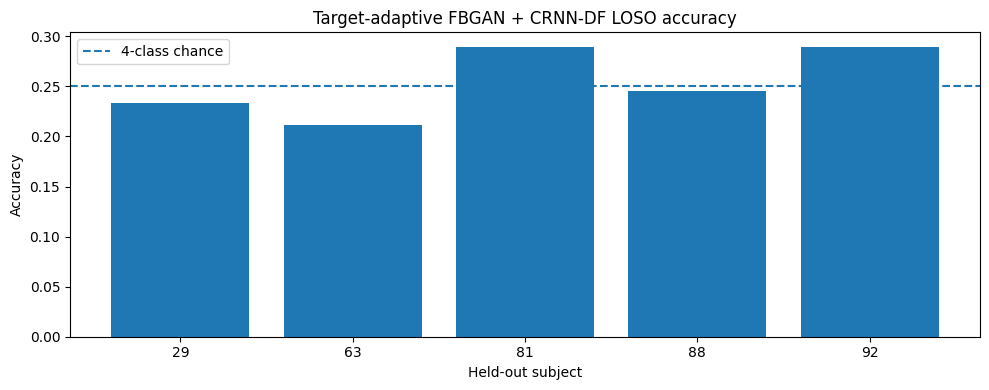

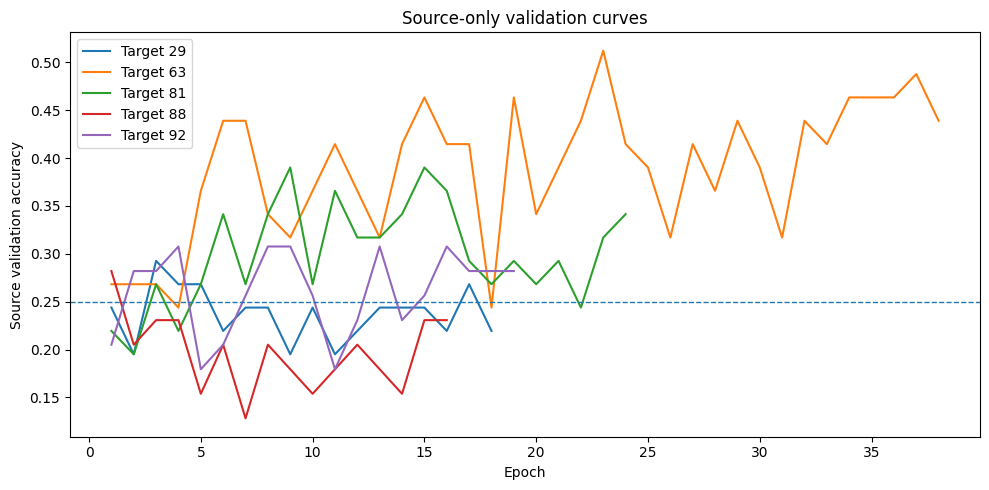

              precision    recall  f1-score   support

   Left Fist       0.25      0.40      0.31       123
  Right Fist       0.15      0.05      0.07       126
  Both Fists       0.41      0.09      0.14       125
   Both Feet       0.26      0.49      0.34       124

    accuracy                           0.26       498
   macro avg       0.27      0.26      0.22       498
weighted avg       0.27      0.26      0.22       498



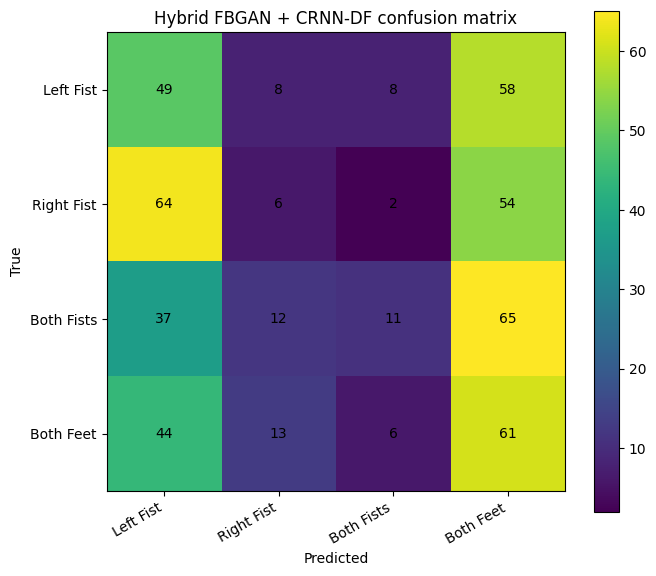

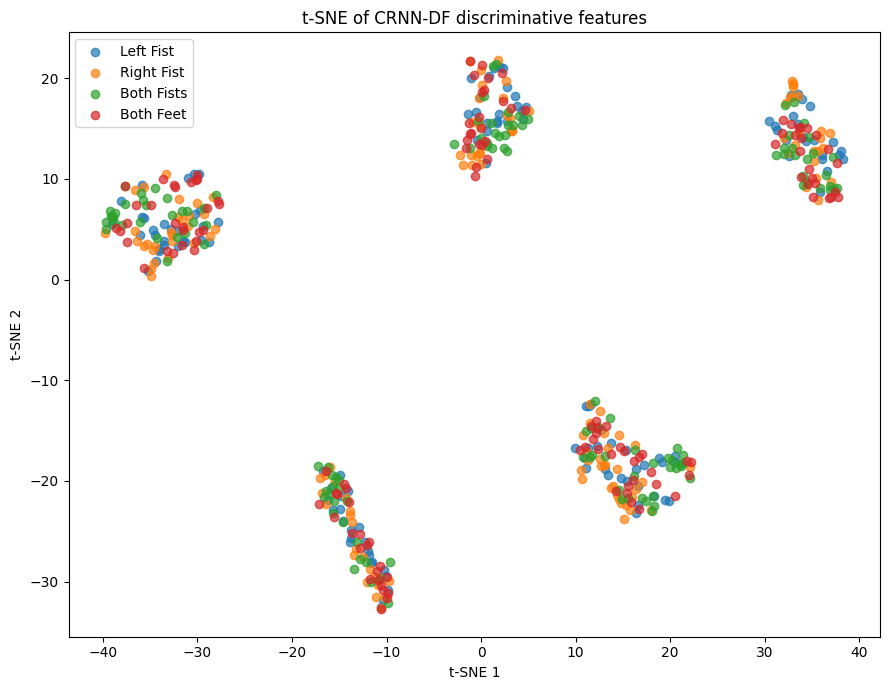


FINAL SUMMARY
{'mean_accuracy': 0.2536842105263158, 'std_accuracy': 0.03468432835285808, 'mean_balanced_accuracy': 0.25493622777355907, 'n_folds': 5, 'fake_per_class': 750, 'total_fake_per_target': 3000}


In [10]:
# CELL 9 - Evaluation, Confusion Matrix, Curves, and t-SNE
# ============================================================


def plot_hybrid_results(
    fold_df,
    history_df,
):
    plt.figure(figsize=(10, 4))

    plt.bar(
        fold_df[
            "test_subject"
        ].astype(str),
        fold_df[
            "accuracy"
        ],
    )

    plt.axhline(
        0.25,
        linestyle="--",
        linewidth=1.5,
        label="4-class chance",
    )

    plt.xlabel(
        "Held-out subject"
    )
    plt.ylabel(
        "Accuracy"
    )
    plt.title(
        "Target-adaptive FBGAN + CRNN-DF LOSO accuracy"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))

    for subject in sorted(
        history_df[
            "test_subject"
        ].unique()
    ):
        subset = history_df[
            history_df[
                "test_subject"
            ]
            == subject
        ]

        plt.plot(
            subset["epoch"],
            subset[
                "source_val_accuracy"
            ],
            label=(
                f"Target {subject}"
            ),
        )

    plt.axhline(
        0.25,
        linestyle="--",
        linewidth=1.0,
    )

    plt.xlabel(
        "Epoch"
    )
    plt.ylabel(
        "Source validation accuracy"
    )
    plt.title(
        "Source-only validation curves"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_predictions(
    predictions_df,
):
    y_true = predictions_df[
        "true"
    ].to_numpy()

    y_pred = predictions_df[
        "pred"
    ].to_numpy()

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                CLASS_NAMES[i]
                for i in range(
                    CFG.n_classes
                )
            ],
            zero_division=0,
        )
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
    )

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(matrix)

    plt.colorbar()

    plt.xticks(
        range(CFG.n_classes),
        [
            CLASS_NAMES[i]
            for i in range(
                CFG.n_classes
            )
        ],
        rotation=30,
        ha="right",
    )

    plt.yticks(
        range(CFG.n_classes),
        [
            CLASS_NAMES[i]
            for i in range(
                CFG.n_classes
            )
        ],
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.title(
        "Hybrid FBGAN + CRNN-DF confusion matrix"
    )

    for row in range(
        matrix.shape[0]
    ):
        for column in range(
            matrix.shape[1]
        ):
            plt.text(
                column,
                row,
                str(
                    matrix[
                        row,
                        column,
                    ]
                ),
                ha="center",
                va="center",
            )

    plt.tight_layout()
    plt.show()


def plot_tsne(
    predictions_df,
    random_state=SEED,
):
    features = np.stack(
        predictions_df[
            "feature"
        ].to_numpy()
    )

    labels = predictions_df[
        "true"
    ].to_numpy()

    perplexity = min(
        30,
        max(
            5,
            len(features) // 5,
        ),
    )

    perplexity = min(
        perplexity,
        len(features) - 1,
    )

    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(
        features
    )

    plt.figure(
        figsize=(9, 7)
    )

    for class_id in range(
        CFG.n_classes
    ):
        mask = (
            labels == class_id
        )

        plt.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            label=CLASS_NAMES[
                class_id
            ],
            alpha=0.70,
        )

    plt.title(
        "t-SNE of CRNN-DF discriminative features"
    )
    plt.xlabel(
        "t-SNE 1"
    )
    plt.ylabel(
        "t-SNE 2"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_hybrid_results(
    FOLD_DF,
    HISTORY_DF,
)

evaluate_predictions(
    PREDICTIONS_DF,
)

plot_tsne(
    PREDICTIONS_DF,
)

print("\nFINAL SUMMARY")
print(SUMMARY)


## Research sources

The implementation follows the reported Zhang et al. (2023) framework: 10-band FBCSP, OVR-CSP, LASSO-selected sparse spatial filters, target-specific FBGAN with raw and filter-bank discriminators, and CRNN-DF with discriminative features. The paper reports 63.52 ± 10.70% for CRNN-DF and 72.82 ± 10.44% after adding 3,000 generated samples on BCI Competition IV-2a. See: https://www.frontiersin.org/articles/10.3389/fnins.2023.1124089/full

PhysioNet EEGBCI uses runs 4/8/12 for left-vs-right motor imagery and runs 6/10/14 for hands-vs-feet motor imagery; subjects are numbered 1-109. See MNE documentation: https://mne.tools/stable/generated/mne.datasets.eegbci.load_data.html